# SETUP

In [1]:
# Import main libs
import os
# Avoid PyTensor compiling error on eCryptfs
os.environ["NUMBA_CACHE_DIR"] = "/tmp/numba_cache"
os.environ["PYTENSOR_FLAGS"] = "base_compiledir=/tmp/pytensor_cache"
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from linearmodels import IV2SLS
import arviz as az
import preliz as pz
import pymc as pm
import xarray as xr
import pytensor.tensor as pt
az.style.use("preliz-doc")

In [2]:
# Define constants
PYMC_MODELS_PATH: str = "pymc_models"
Path(PYMC_MODELS_PATH).mkdir(parents=True, exist_ok=True)
SEED: int = 5
ROOT_PATH = Path.cwd()
print(f"Root path = {ROOT_PATH}")
N_CORES: int = os.cpu_count()
print(f"Number of cores = {N_CORES}")
N_CHAINS: int = int(N_CORES / 4)
print(f"Number of chains = {N_CHAINS}")

Root path = /home/gus-cunha/Projects/bayesian_causal_inference_study
Number of cores = 16
Number of chains = 4


# DIFFERENCE IN DIFFERENCES

In [4]:
# Load data
df_did = pd.read_csv(
    os.path.join(ROOT_PATH, "data", "causal_inference_in_python_linear_did.csv")
).astype(
    {"date":"datetime64[ns]"}
)
df_did

,date,city,region,treated,tau,downloads,post
0,2021-05-01,5,S,0,0.000000,51.0,0
1,2021-05-02,5,S,0,0.000000,51.0,0
2,2021-05-03,5,S,0,0.000000,51.0,0
3,2021-05-04,5,S,0,0.000000,50.0,0
4,2021-05-05,5,S,0,0.000000,49.0,0
...,...,...,...,...,...,...,...
1627,2021-05-28,197,S,1,1.771233,53.0,1
1628,2021-05-29,197,S,1,1.771233,52.0,1
1629,2021-05-30,197,S,1,1.771233,54.0,1
1630,2021-05-31,197,S,1,1.771233,53.0,1


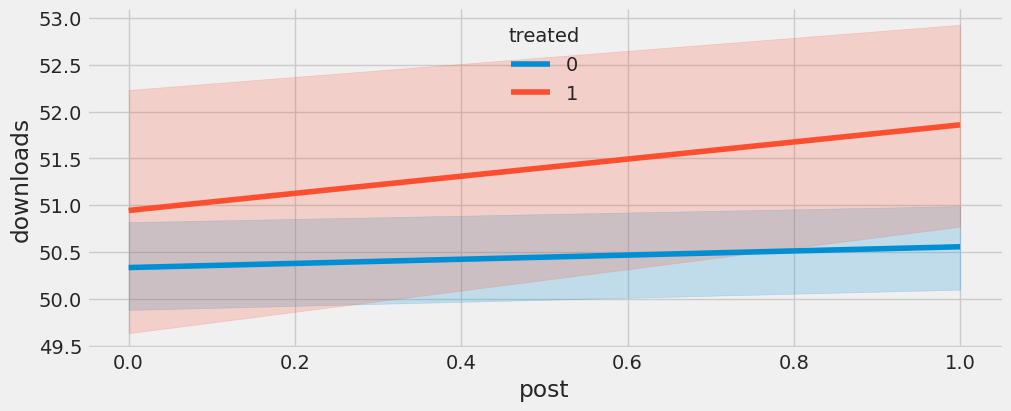

,city,post,downloads,date,treated
0,5,0,50.642857,2021-05-01,0
1,5,1,50.166667,2021-05-15,0
2,15,0,49.142857,2021-05-01,0
3,15,1,49.166667,2021-05-15,0
4,20,0,48.785714,2021-05-01,0
...,...,...,...,...,...
97,195,1,53.777778,2021-05-15,0
98,196,0,52.214286,2021-05-01,0
99,196,1,52.333333,2021-05-15,0
100,197,0,51.071429,2021-05-01,1


In [37]:
# Group data by city and post flag
did_modelling = df_did.groupby(
    by=["city", "post"]
).agg({
        "downloads":"mean", "date": "min", "treated": "max"
}).reset_index(drop=False)

# Inspect data graphically
with plt.style.context("fivethirtyeight"):
    plt.figure(figsize=(10, 4))
    sns.lineplot(
        data=did_modelling,
        x="post",
        y="downloads",
        hue="treated"
    )
    plt.show()

# Inspect resulting data
did_modelling

In [78]:
###############################
######### FREQUENTIST #########

# Define formula, where T = credit limit
formula = 'downloads ~ treated*post'
# Fit model to data
model = smf.ols(formula, data=did_modelling).fit(
    cov_type='cluster', cov_kwds={'groups': did_modelling['city']}
)
# Inspect results
print(f"Did estimated effect: {model.params["treated:post"]}")
model.summary().tables[1]

Did estimated effect: 0.6917359536407216


,coef,std err,z,P>|z|,[0.025,0.975]
Intercept,50.3350,0.248,203.011,0.000,49.849,50.821
treated,0.6094,0.709,0.859,0.390,-0.780,1.999
post,0.2218,0.050,4.400,0.000,0.123,0.321
treated:post,0.6917,0.200,3.464,0.001,0.300,1.083


Std of the target: 1.6639836474330774


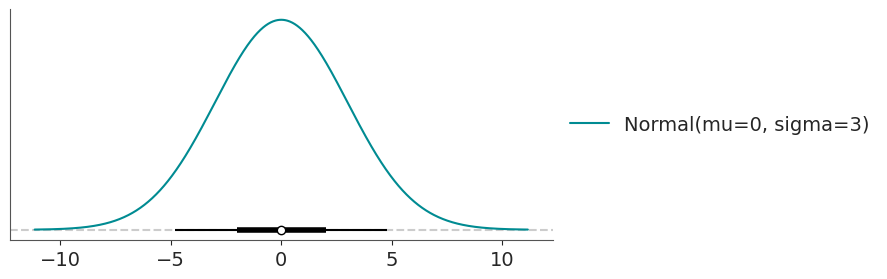

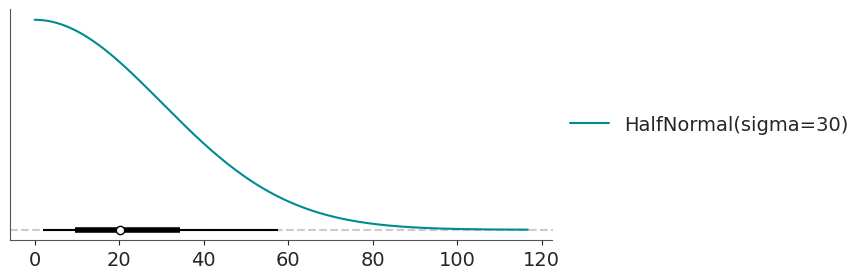

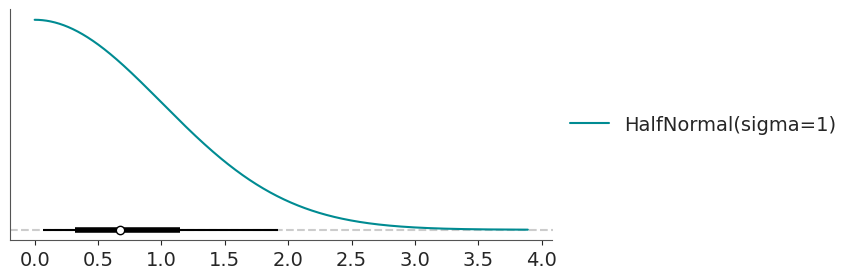

In [20]:
##########################
######### PRIORS #########

print(f"Std of the target: {did_modelling.downloads.std(ddof=1)}")
pz.Normal(mu=0, sigma=3).plot_pdf(pointinterval=True,figsize=(7, 3))
plt.show()
pz.HalfNormal(sigma=30).plot_pdf(pointinterval=True,figsize=(7, 3))
plt.show()
pz.HalfNormal(sigma=1).plot_pdf(pointinterval=True,figsize=(7, 3))
plt.show()

In [ ]:
############################
######### BAYESIAN #########

with pm.Model() as model_did:
    # Priors
    α = pm.HalfNormal("α", sigma=30)
    β_treated = pm.Normal("β_treated", mu=0, sigma=3)
    β_post = pm.Normal("β_post", mu=0, sigma=3)
    β_treated_interaction_post = pm.Normal("β_treated_interaction_post", mu=0, sigma=3)
    σ = pm.HalfNormal("σ", sigma=1)
    # Likelihood
    μ = (
        α + 
        β_treated * did_modelling.treated + 
        β_post * did_modelling.post + 
        β_treated_interaction_post * did_modelling.treated * did_modelling.post
    )
    y_pred = pm.Normal("y_pred", mu=μ, sigma=σ, observed=did_modelling.downloads)
    # MCMC sampling
    idata_did = pm.sample(
        nuts_sampler="nutpie",
        draws=4_000,
        tune=1_000,
        chains=N_CHAINS,
        cores=N_CHAINS,
        random_seed=SEED,
        progressbar=True,
        discard_tuned_samples=True,
        return_inferencedata=True,
        idata_kwargs={"log_likelihood": True}
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [α, β_treated, β_post, β_treated_interaction_post, σ]


Output()

/home/gus-cunha/.pyenv/versions/3.12.3/envs/bayesian_causal_inference_study/lib/python3.12/site-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(
Sampling 4 chains for 1_000 tune and 4_000 draw iterations (4_000 + 16_000 draws total) took 4 seconds.


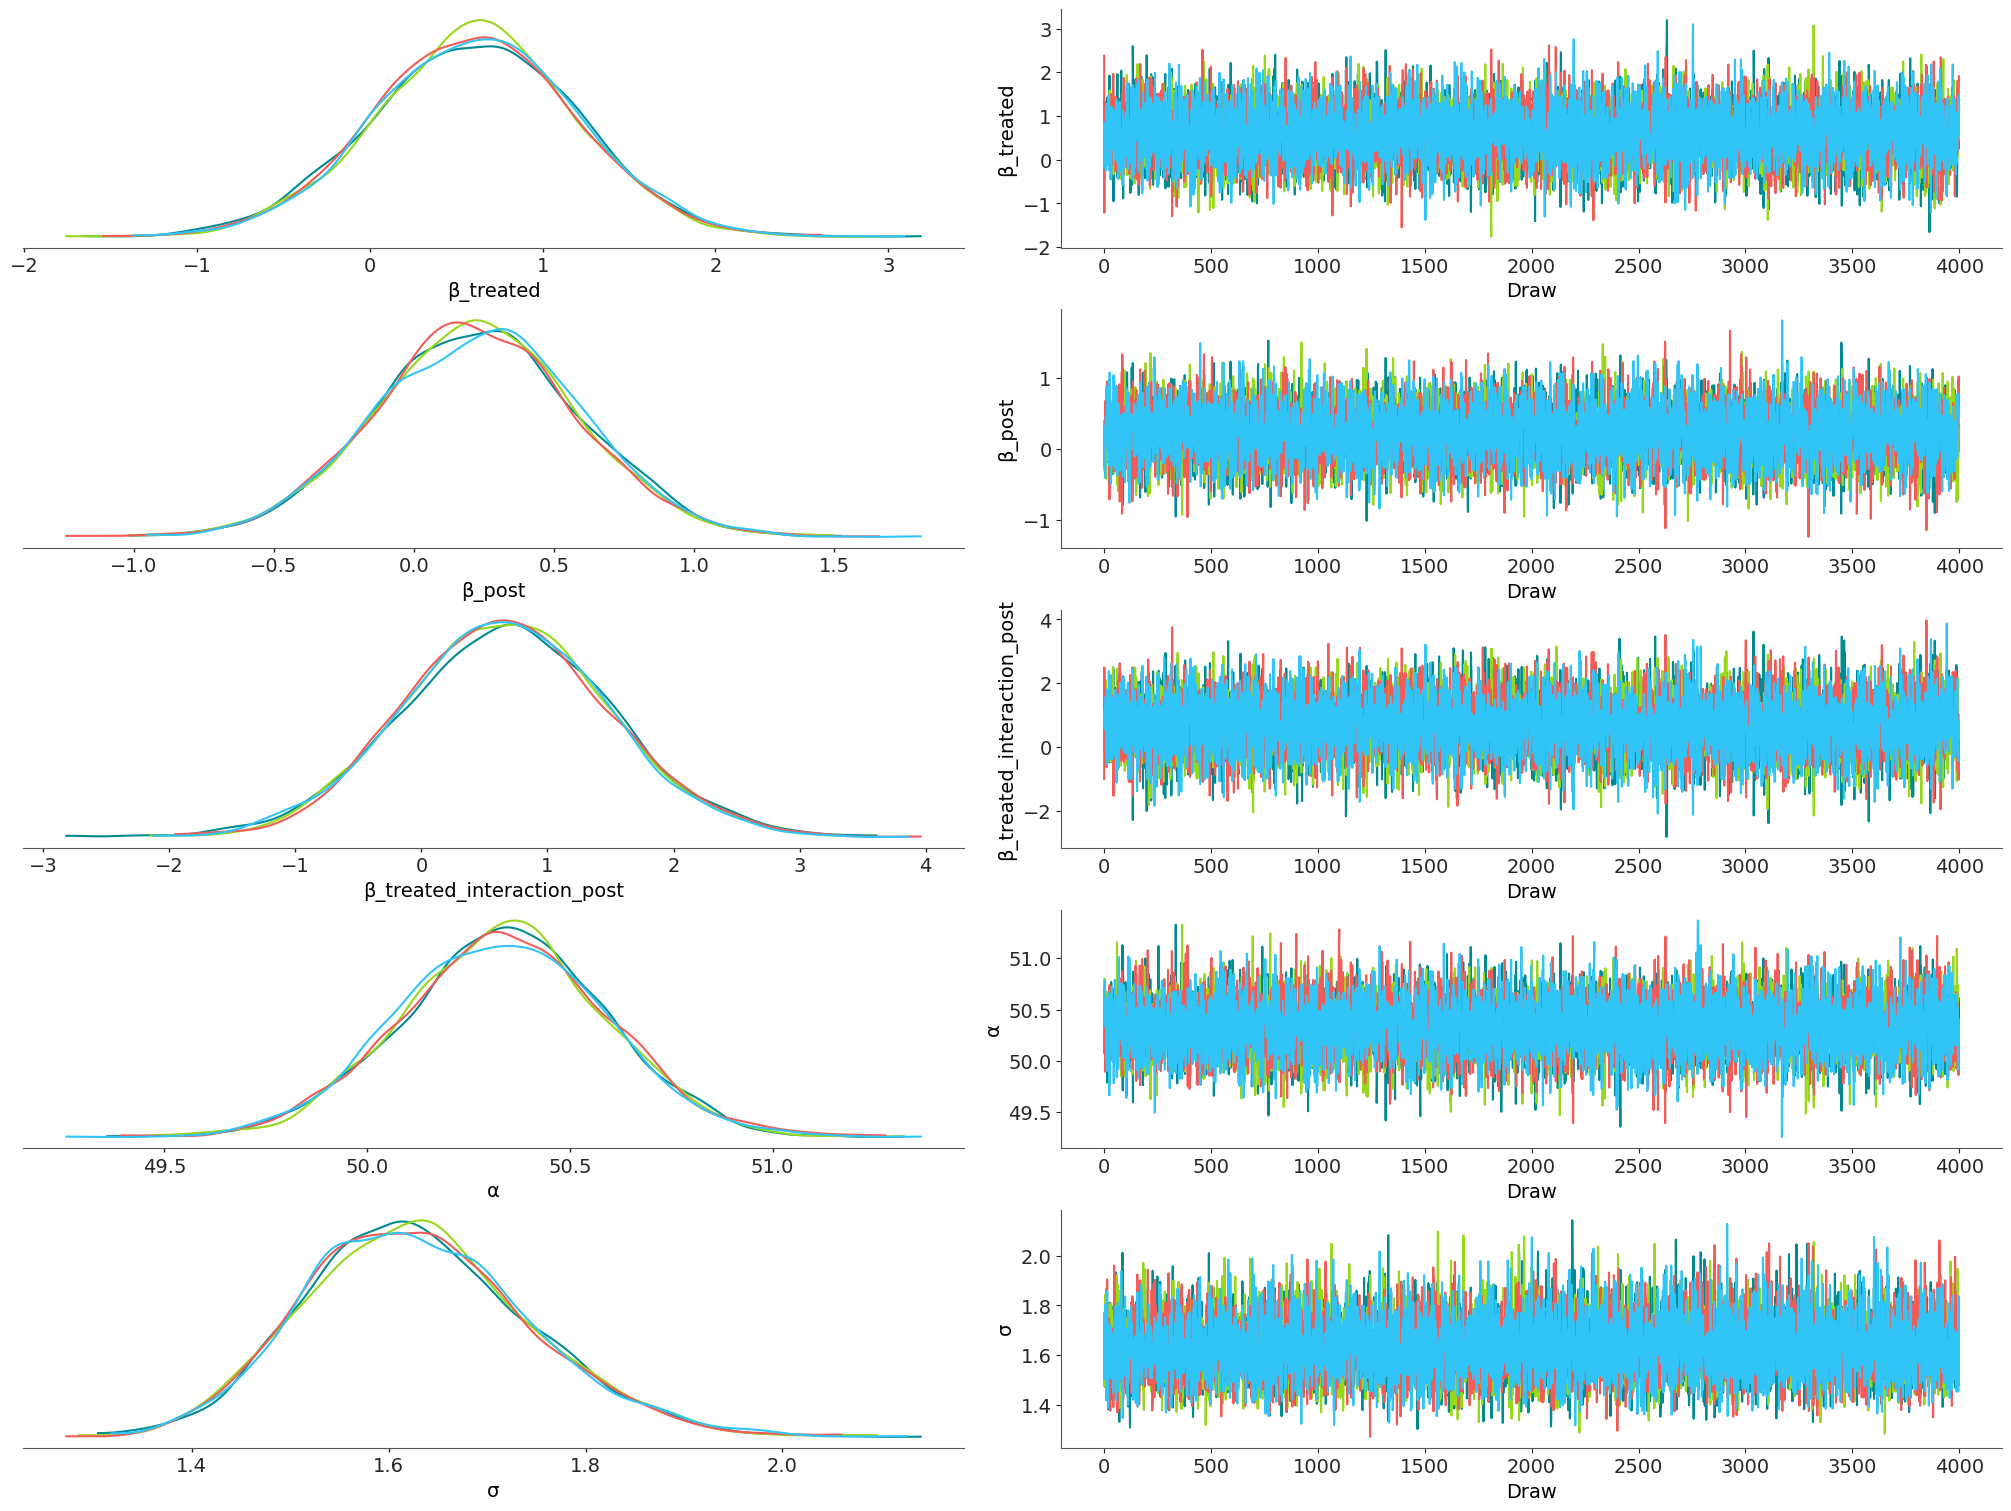

In [35]:
# Plot traces for convergence checking
az.plot_trace_dist(
    dt=idata_did,
    var_names=None, filter_vars=None,
    group='posterior', coords=None, sample_dims=None,
    compact=False, combined=False, kind=None, stats=None,
    figure_kwargs={"figsize": (20, 15)},
);

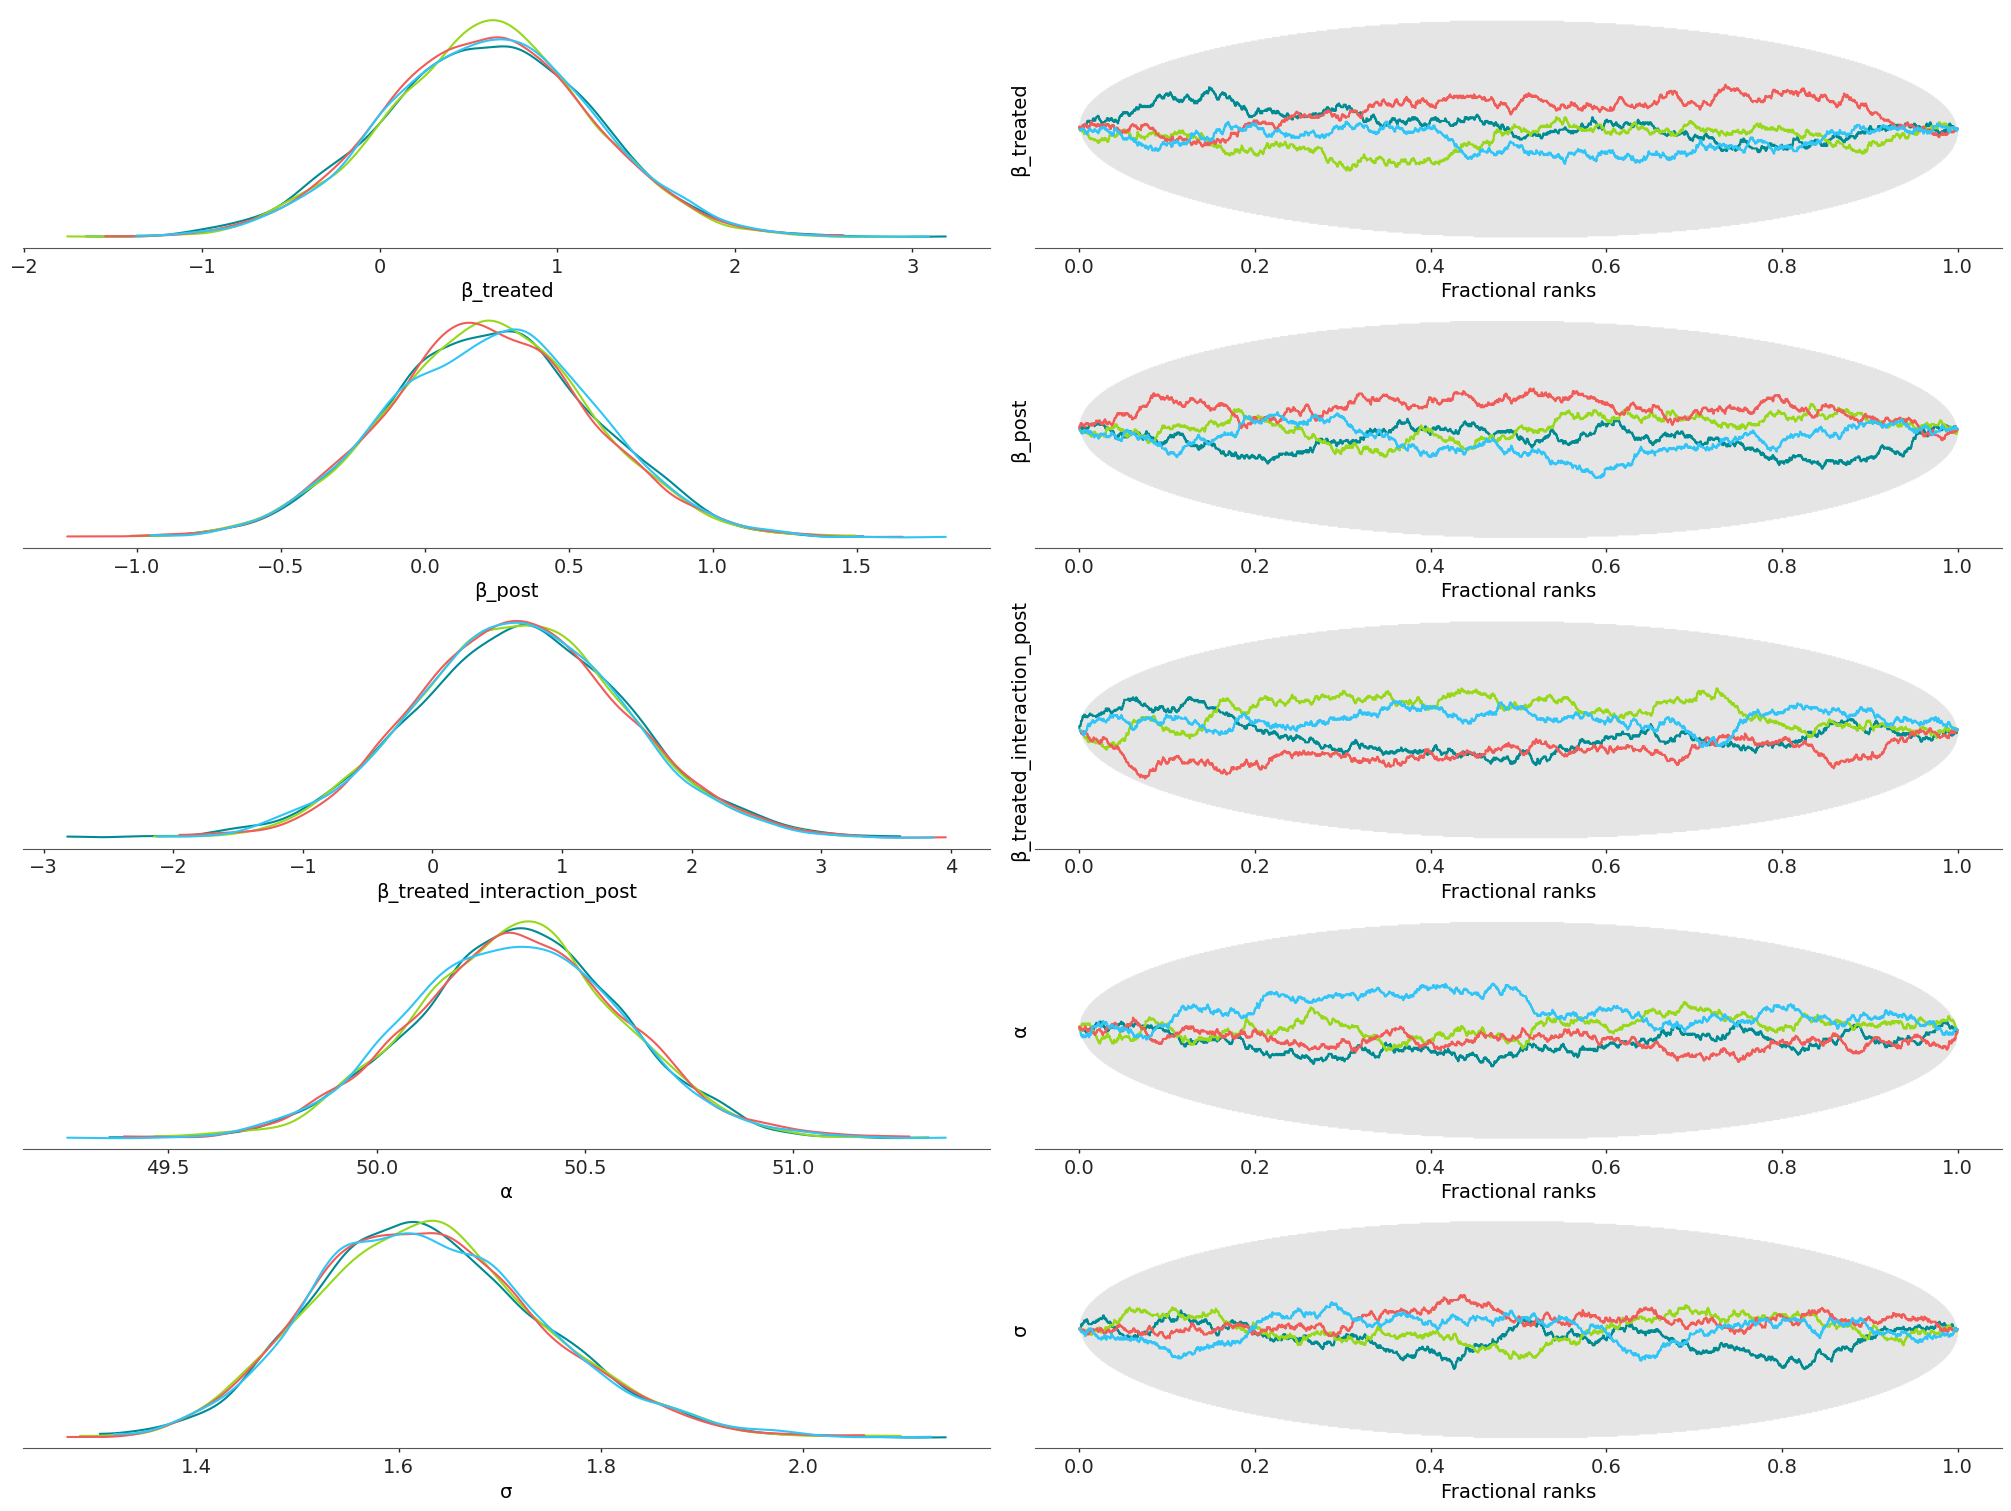

In [38]:
# Plot traces for convergence checking
az.plot_rank_dist(
    dt=idata_did,
    var_names=None, filter_vars=None,
    group='posterior', coords=None, sample_dims=None,
    compact=False, combined=False, kind=None, stats=None,
    figure_kwargs={"figsize": (20, 15)},
);

In [39]:
# Inspect summary
# R hat
#   compute the variance between chains with the variance within chains
#   Ideally = 1, okay if < 1.01
# ESS (Effective Sample Size)
#   Less than the draws due to autocorrelation
#   At least 400 (100 ESS per chain) -> the higher the better
# MCSE - Monte Carlo Standard Error
#   Error introduced on MC posterior due to 
#   finite sampling and samples not being truely independent
#   It impact the precision of results
#   The pass criteria to check:
#       mcse_mean / sd (from the same table) below ~5–10%
#       If those all pass (R hat, ESS and MCSE), a U shape MCSE plot is fine as-is
#       the shape is just the normal signature of tail quantiles being harder to pin down.
summary = az.summary(
    data=idata_did,
    var_names=None, filter_vars=None,
    group='posterior', coords=None, sample_dims=None,
    kind='all', fmt='wide', ci_prob=0.95, ci_kind="hdi",
    round_to='auto', skipna=False
)

# Relative MCSE: how big is the sampling error compared to the posterior's own spread?
#   mcse_mean_pct = MCSE of the posterior mean, as a % of the posterior SD.
#       Rule of thumb: < 5–10% is fine; 
#       higher means you'd need more draws to trust the reported mean/HDI to that many significant digits.
#   mcse_sd_pct = same idea for the SD estimate.
summary["mcse_mean_pct"] = summary["mcse_mean"].astype(float) / summary["sd"].astype(float)
summary["mcse_sd_pct"]   = summary["mcse_sd"].astype(float)   / summary["sd"].astype(float)
summary

,mean,sd,hdi95_lb,hdi95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd,mcse_mean_pct,mcse_sd_pct
β_treated,0.61,0.585,-0.55,1.7,11395,11618,1.00,0.0055,0.0039,0.009402,0.006667
β_post,0.225,0.361,-0.48,0.93,10487,10982,1.00,0.0035,0.0025,0.009695,0.006925
β_treated_interaction_post,0.67,0.82,-0.92,2.3,11088,11255,1.00,0.0078,0.0057,0.009512,0.006951
α,50.335,0.253,50,51,10880,11165,1.00,0.0024,0.0018,0.009486,0.007115
σ,1.63,0.115,1.4,1.9,14529,11658,1.00,0.00095,0.00071,0.008261,0.006174


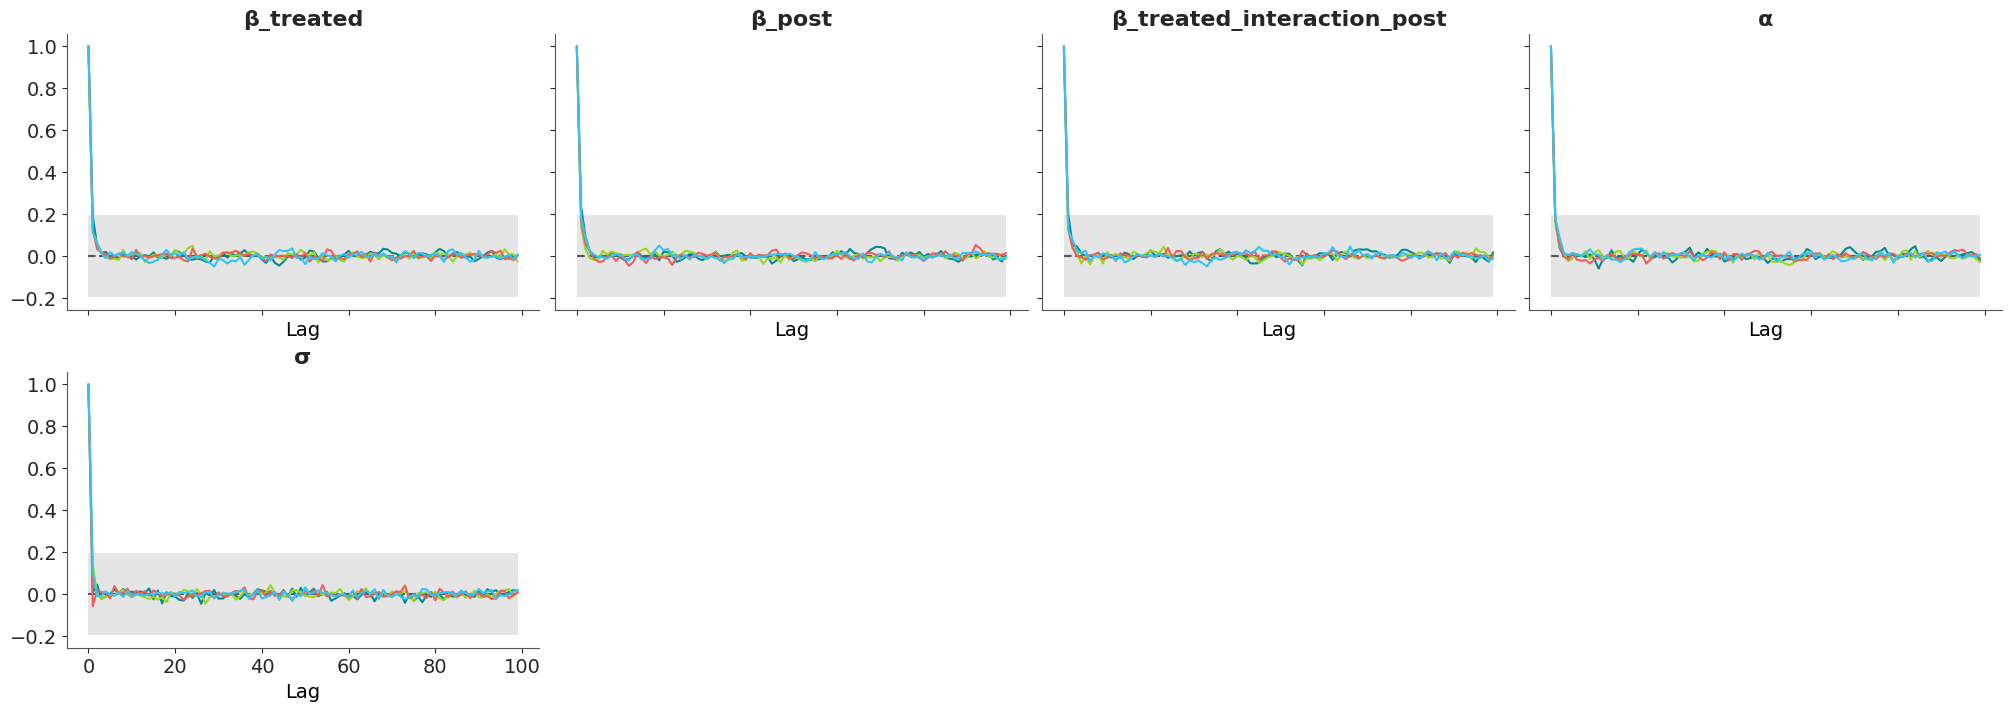

In [40]:
# Inspect autocorrelation
az.plot_autocorr(
    dt=idata_did, 
    var_names=None, filter_vars=None,
    group='posterior', coords=None, sample_dims=None,
    max_lag=None,
    figure_kwargs={"figsize": (20, 7)}
);

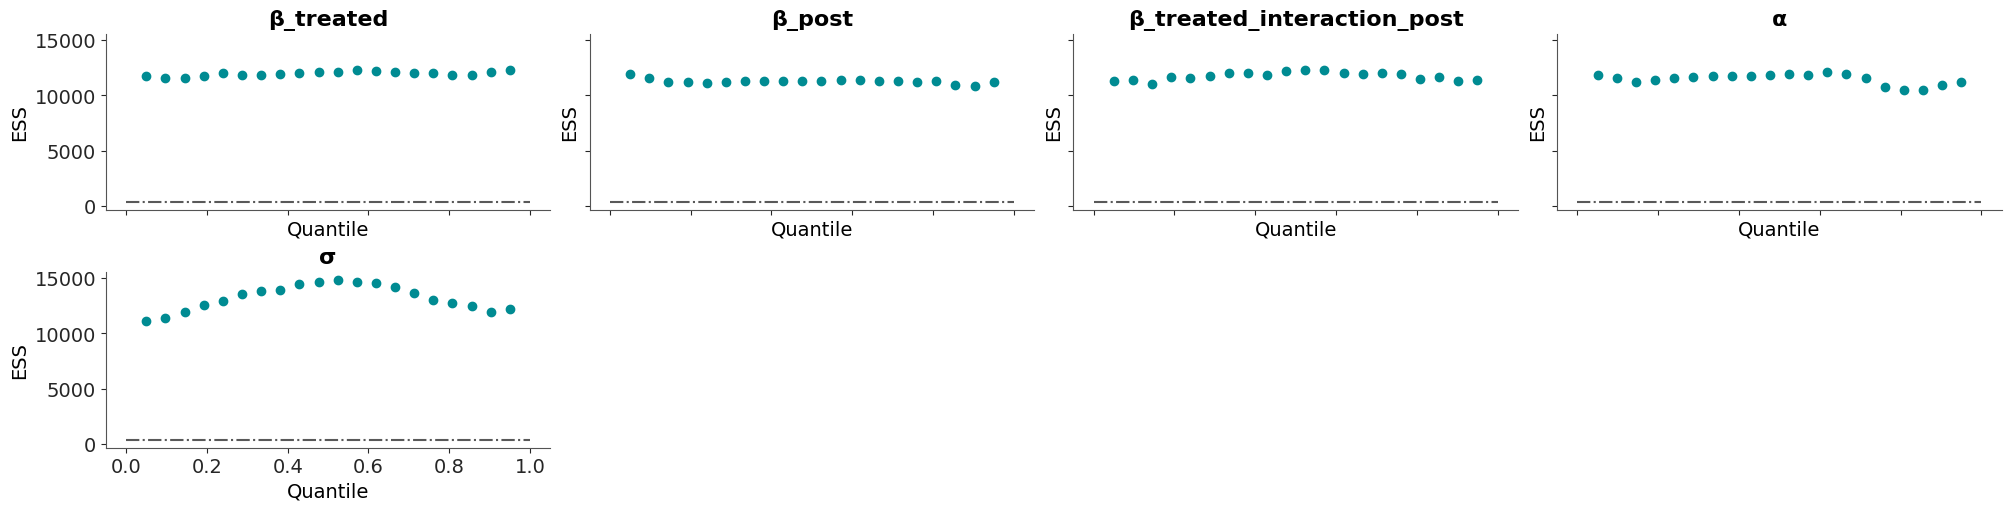

In [41]:
# Inspect ESS
# ESS (Effective Sample Size)
#   Less than the draws due to autocorrelation
#   At least 400 (100 ESS per chain) -> the higher the better
az.plot_ess(
    dt=idata_did, 
    var_names=None, filter_vars=None,
    group='posterior', coords=None, sample_dims=None,
    kind='quantile', relative=False,
    extra_methods=False,    
    rug=False, rug_kind='diverging',
    n_points=20, min_ess=N_CHAINS*100, stats=None,
    figure_kwargs={"figsize": (20, 5)},
);

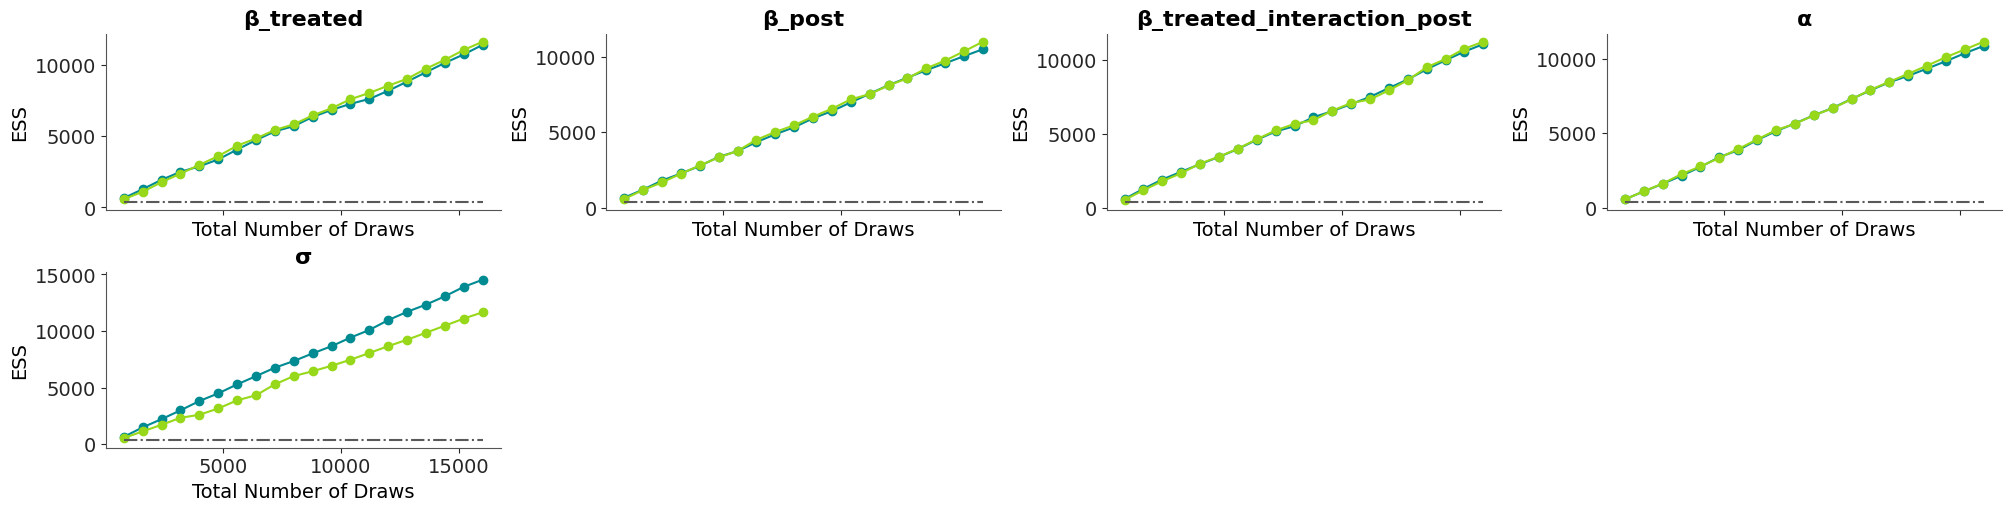

In [42]:
# Inspect ESS evolution
# ESS (Effective Sample Size)
#   Less than the draws due to autocorrelation
#   At least 400 (100 ESS per chain) -> the higher the better
az.plot_ess_evolution(
    dt=idata_did, 
    var_names=None, filter_vars=None,
    group='posterior', coords=None, sample_dims=None,
    relative=False,
    extra_methods=False,
    n_points=20, min_ess=N_CHAINS*100,
    stats=None,
    figure_kwargs={"figsize": (20, 5)},
);

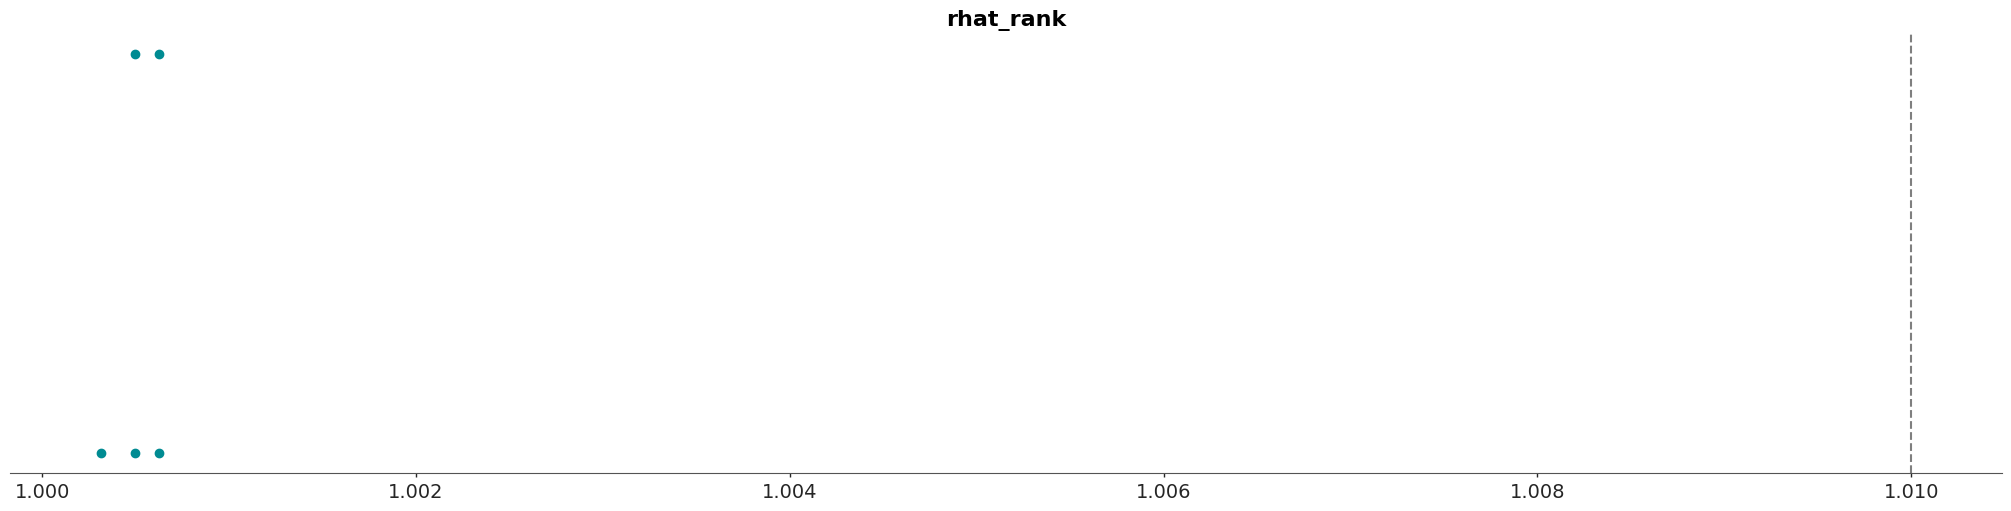

In [43]:
# Plot R hat convergence
# R hat
#   compute the variance between chains with the variance within chains
#   Ideally = 1, okay if < 1.01
az.plot_convergence_dist(
    dt=idata_did, 
    var_names=None, filter_vars=None,
    group='posterior', coords=None, sample_dims=None, ref_line=True,
    diagnostics=["rhat_rank"],
    grouped=True, #kind='ecdf',
    kind="dot",
    point_estimate=None, ci_kind=None, ci_prob=None,
    stats=None,
    figure_kwargs={"figsize": (20, 5)},
);

,mcse_mean_pct,mcse_sd_pct
β_treated,0.009402,0.006667
β_post,0.009695,0.006925
β_treated_interaction_post,0.009512,0.006951
α,0.009486,0.007115
σ,0.008261,0.006174


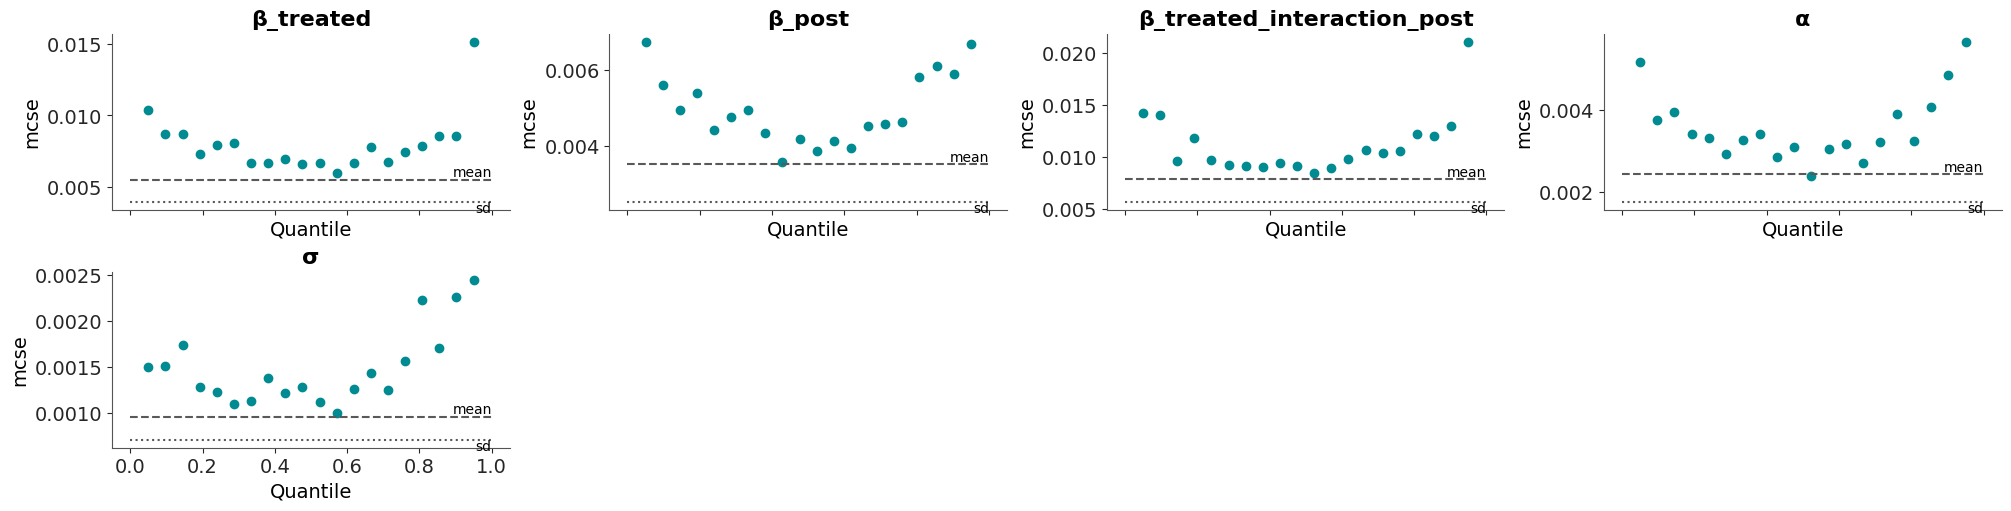

In [44]:
# Inspect MCSE - Monte Carlo Standard Error
#   Error introduced on MC posterior due to 
#   finite sampling and samples not being truely independent
#   It impact the precision of results
# extra_methods overlays two dashed horizontal lines per subplot:
#   the MCSE of the posterior mean, and 
#   the MCSE of the posterior sd. 
#   if your quantile-based MCSE curve sits near or below these lines,
#   you're in good shape; if it spikes well above them 
#   (especially at the tails, as in your α and σ panels),
#   that quantile's estimate is comparatively less precise.
#   The pattern with quantile MCSE tracing a U-shape, 
#   worse at the tails (0.05/0.95) than the middle, 
#   and sitting above both the mean-MCSE and sd-MCSE reference lines — is the expected, 
#   typical shape, not a red flag by itself. It reflects real statistical facts:
#   Tail quantiles always have lower effective sample size than central quantiles/the mean, since fewer draws inform them.
#       The posterior mean is usually the most efficiently estimated summary statistic,
#       so mean-MCSE is the lowest baseline; sd and quantiles are inherently noisier estimators.
#       So "quantile MCSE > mean line > sd line" is normal ordering, not evidence of a sampling problem.
az.plot_mcse(
    dt=idata_did, 
    var_names=None, filter_vars=None,
    group='posterior', coords=None, sample_dims=None,
    extra_methods=True,
    rug=False, rug_kind='diverging',
    n_points=20, stats=None,
    figure_kwargs={"figsize": (20, 5)},
);

# Relative MCSE: how big is the sampling error compared to the posterior's own spread?
#   mcse_mean_pct = MCSE of the posterior mean, as a % of the posterior SD.
#       Rule of thumb: < 5–10% is fine; 
#       higher means you'd need more draws to trust the reported mean/HDI to that many significant digits.
#   mcse_sd_pct = same idea for the SD estimate.
summary = az.summary(
    data=idata_did,
    var_names=None, filter_vars=None,
    group='posterior', coords=None, sample_dims=None,
    kind='all', fmt='wide', ci_prob=0.95, ci_kind="hdi",
    round_to='auto', skipna=False
)
summary["mcse_mean_pct"] = summary["mcse_mean"].astype(float) / summary["sd"].astype(float)
summary["mcse_sd_pct"]   = summary["mcse_sd"].astype(float)   / summary["sd"].astype(float)
summary[["mcse_mean_pct", "mcse_sd_pct"]]

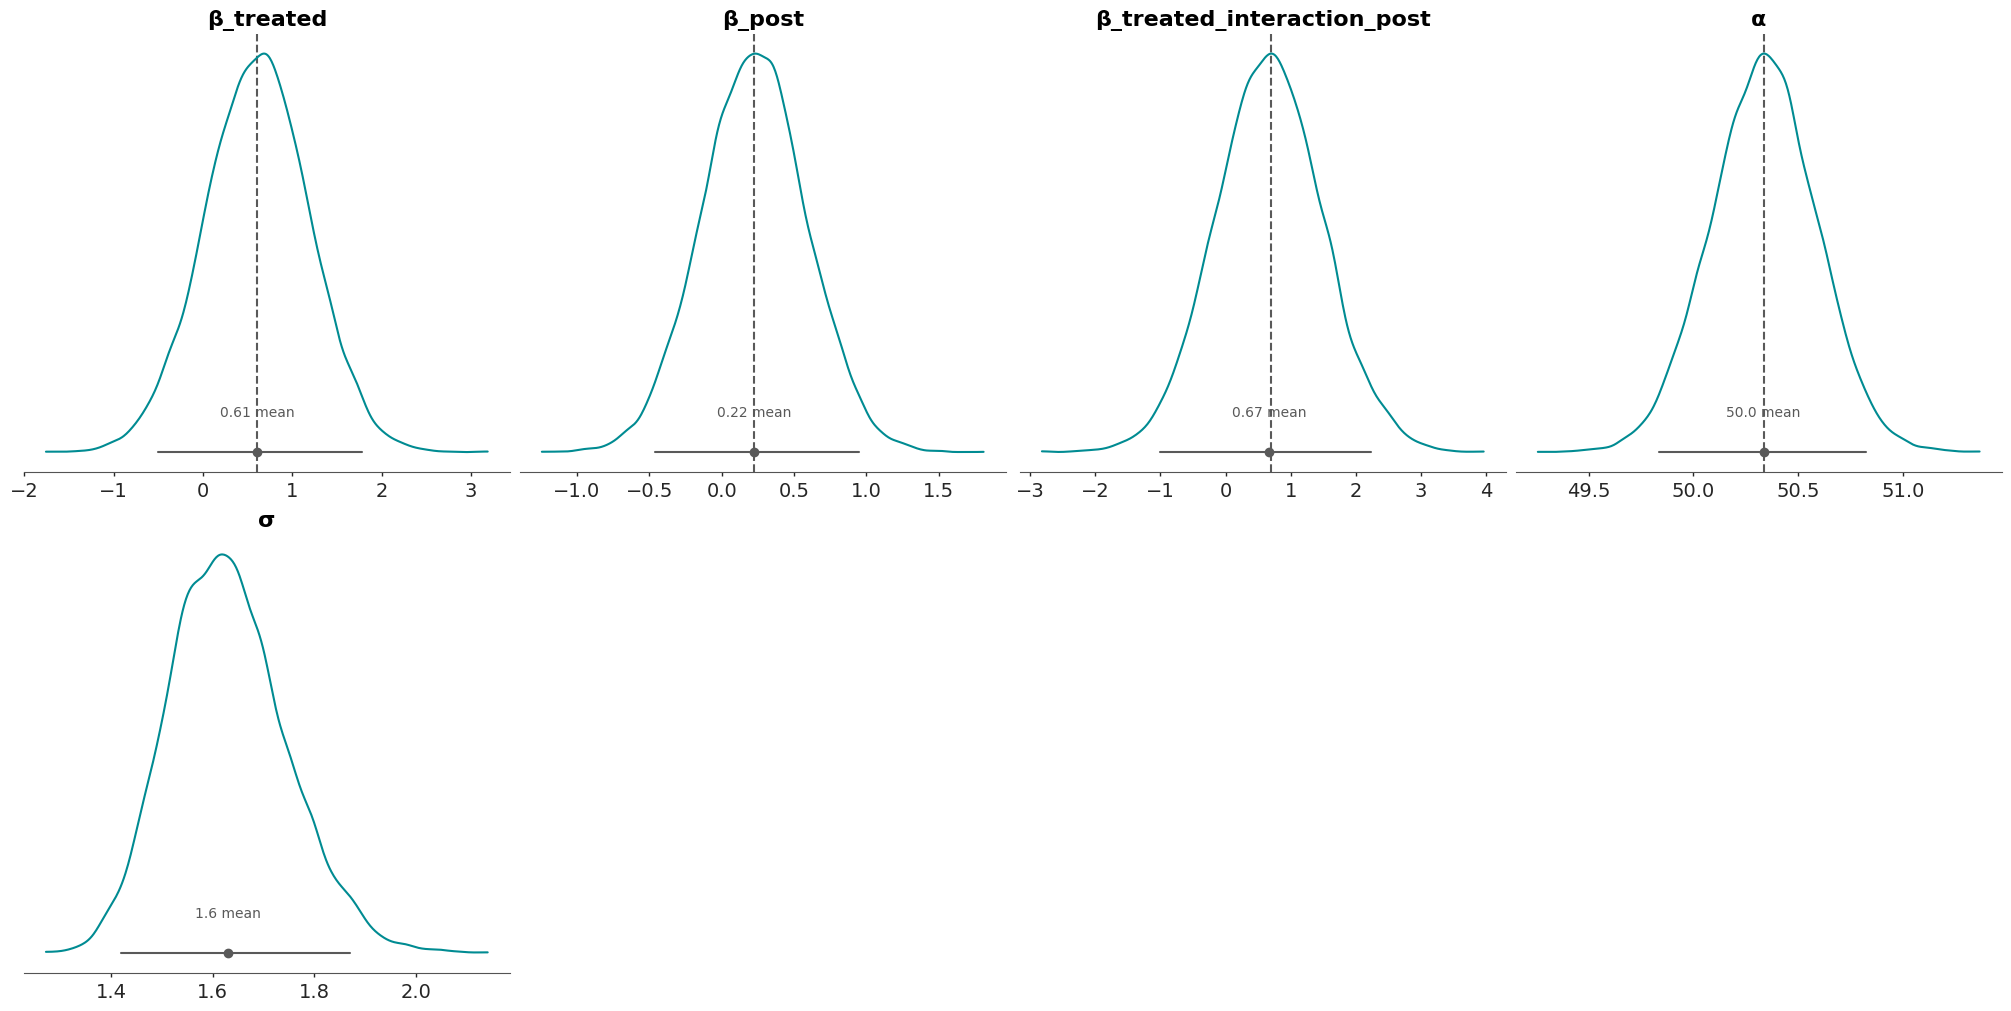

In [79]:
# Inspect posteriors
pc = az.plot_dist(
    dt=idata_did,
    var_names=None, filter_vars=None,
    group='posterior', coords=None,
    sample_dims=None,
    kind=None, point_estimate="mean",
    ci_kind="hdi", ci_prob=0.95, stats=None,
    visuals={"point_estimate_text": True},
    figure_kwargs={"figsize": (20, 10)},
)
az.add_lines(
    plot_collection=pc,
    values={
        "α": model.params["Intercept"],
        "β_treated": model.params["treated"],
        "β_post": model.params["post"],
        "β_treated_interaction_post": model.params["treated:post"]
    },
    orientation="vertical"
);

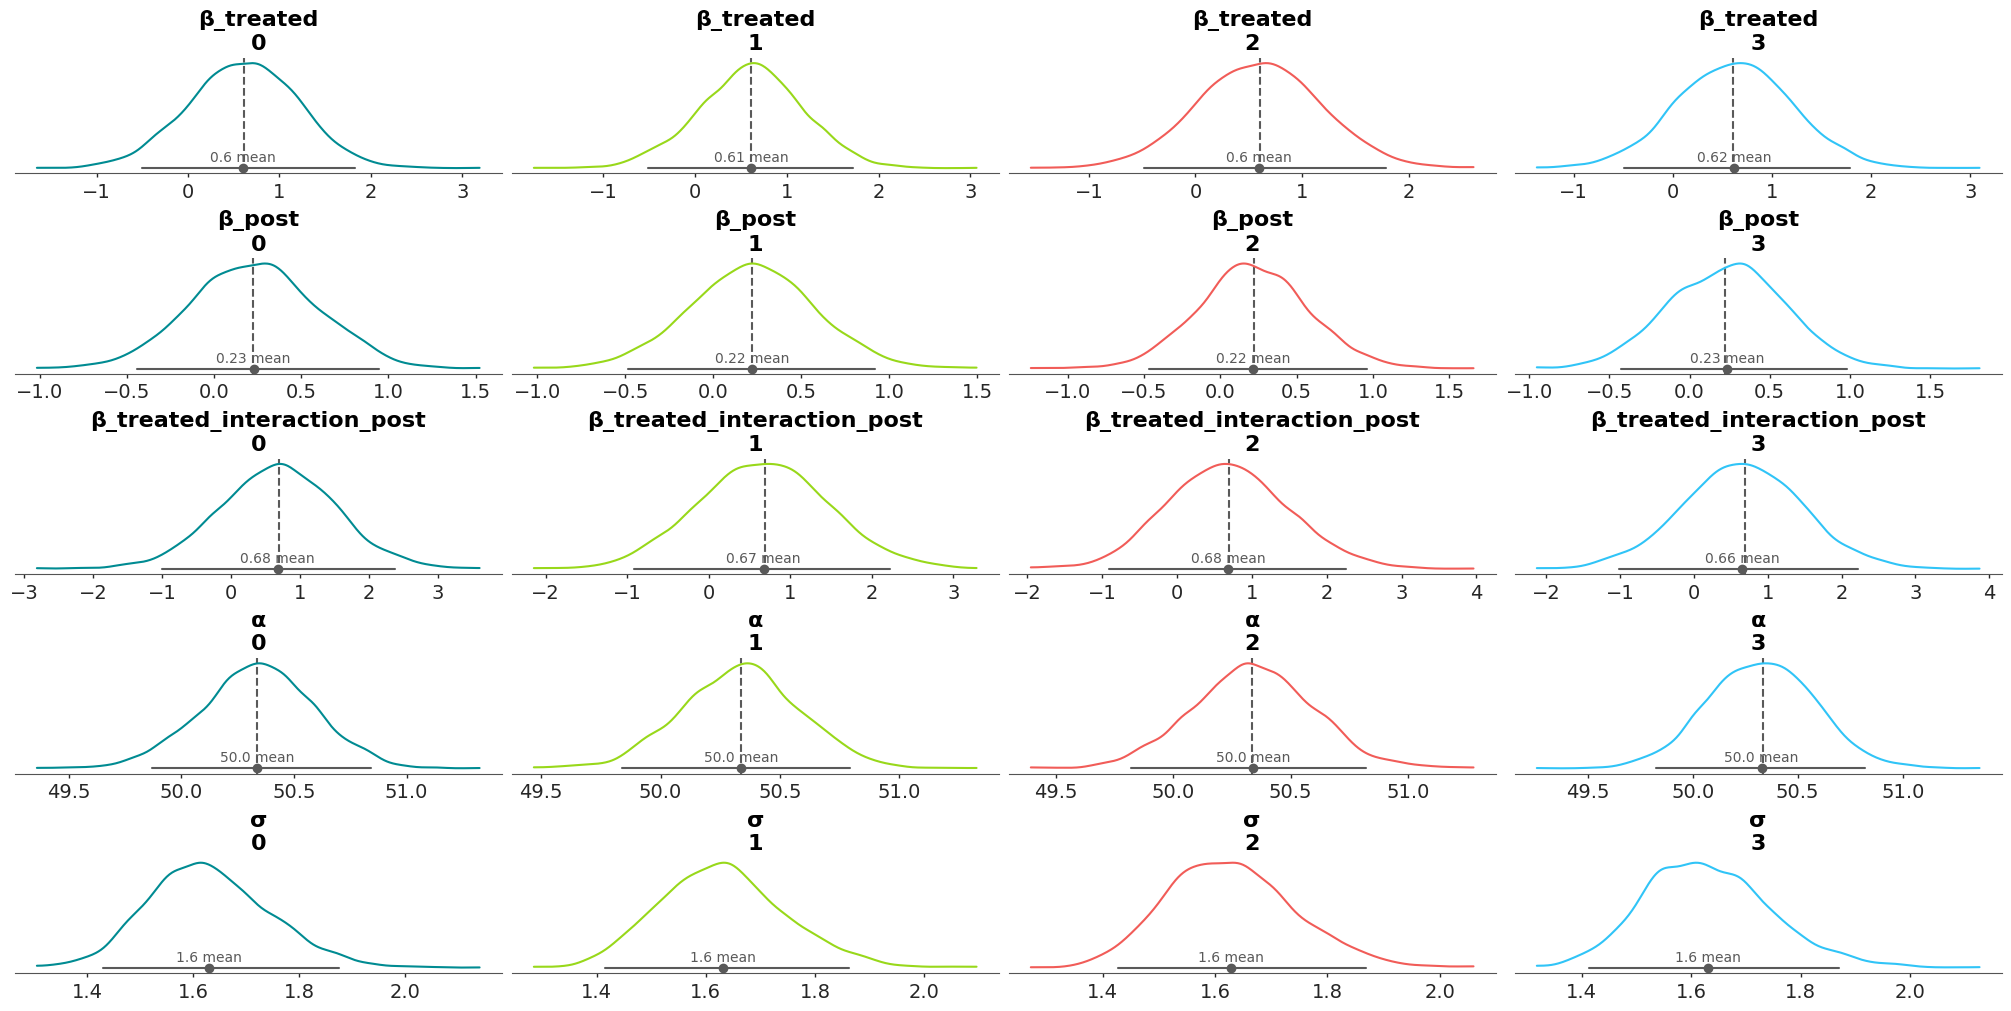

In [ ]:
# Inspect posteriors
pc = az.plot_dist(
    dt=idata_did,
    var_names=None, filter_vars=None,
    group='posterior', coords=None,
    sample_dims=["draw"],
    aes={"color": ["chain"]},
    kind=None, point_estimate="mean",
    ci_kind="hdi", ci_prob=0.95, stats=None,
    visuals={"point_estimate_text": True},
    figure_kwargs={"figsize": (20, 10)},
)
az.add_lines(
    plot_collection=pc,
    values={
        "α": model.params["Intercept"],
        "β_treated": model.params["treated"],
        "β_post": model.params["post"],
        "β_treated_interaction_post": model.params["treated:post"]
    },
    orientation="vertical"
);

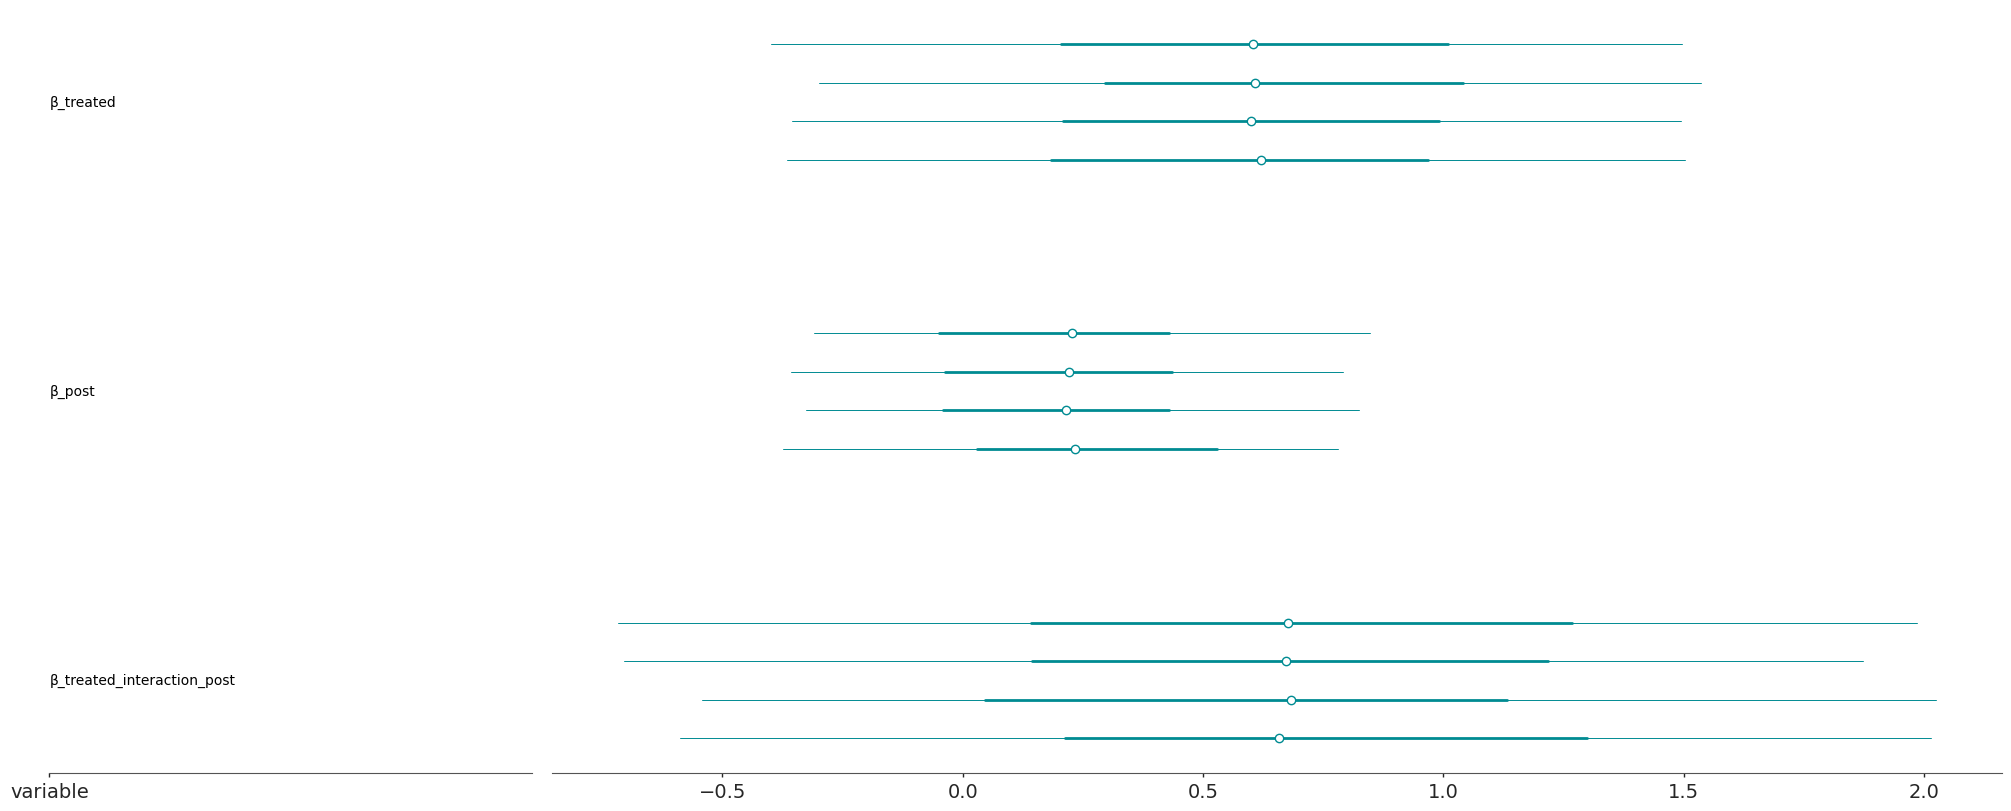

In [52]:
# Plot results
az.plot_forest(
    dt=idata_did, 
    var_names=["~α", "~σ"], filter_vars=None,
    group='posterior', coords=None, sample_dims=None,
    combined=False, point_estimate="mean", ci_kind="hdi", ci_probs=None,
    labels=None, stats=None,
    figure_kwargs={"figsize": (20, 8)},
);

# SYNTHETIC CONTROL

In [3]:
# Load data
df_sc = pd.read_csv(
    os.path.join(ROOT_PATH, "data", "causal_inference_in_python_linear_sc.csv")
).astype(
    {"date":"datetime64[ns]"}
).assign(**{
    # Normalize app download by population size
    "app_download_pct": lambda df: 100 * df["app_download"] / df["population"]
})
# Inspect data
df_sc

,app_download,population,city,state,date,post,treated,app_download_pct
0,3066.0,12396372,sao_paulo,sao_paulo,2022-03-01,0,1,0.024733
1,2701.0,12396372,sao_paulo,sao_paulo,2022-03-02,0,1,0.021789
2,1927.0,12396372,sao_paulo,sao_paulo,2022-03-03,0,1,0.015545
3,1451.0,12396372,sao_paulo,sao_paulo,2022-03-04,0,1,0.011705
4,1248.0,12396372,sao_paulo,sao_paulo,2022-03-05,0,1,0.010067
...,...,...,...,...,...,...,...,...
6095,99.0,481725,maua,sao_paulo,2022-06-26,1,0,0.020551
6096,233.0,481725,maua,sao_paulo,2022-06-27,1,0,0.048368
6097,241.0,481725,maua,sao_paulo,2022-06-28,1,0,0.050029
6098,226.0,481725,maua,sao_paulo,2022-06-29,1,0,0.046915


In [4]:
# Get treated cities
treated_cities = df_sc.loc[df_sc.treated == 1, "city"].unique().tolist()
treated_cities

['sao_paulo', 'porto_alegre', 'joao_pessoa']

In [5]:
# Get treatment date
tr_period = df_sc.loc[df_sc.post==1, "date"].min()
tr_period

Timestamp('2022-05-01 00:00:00')

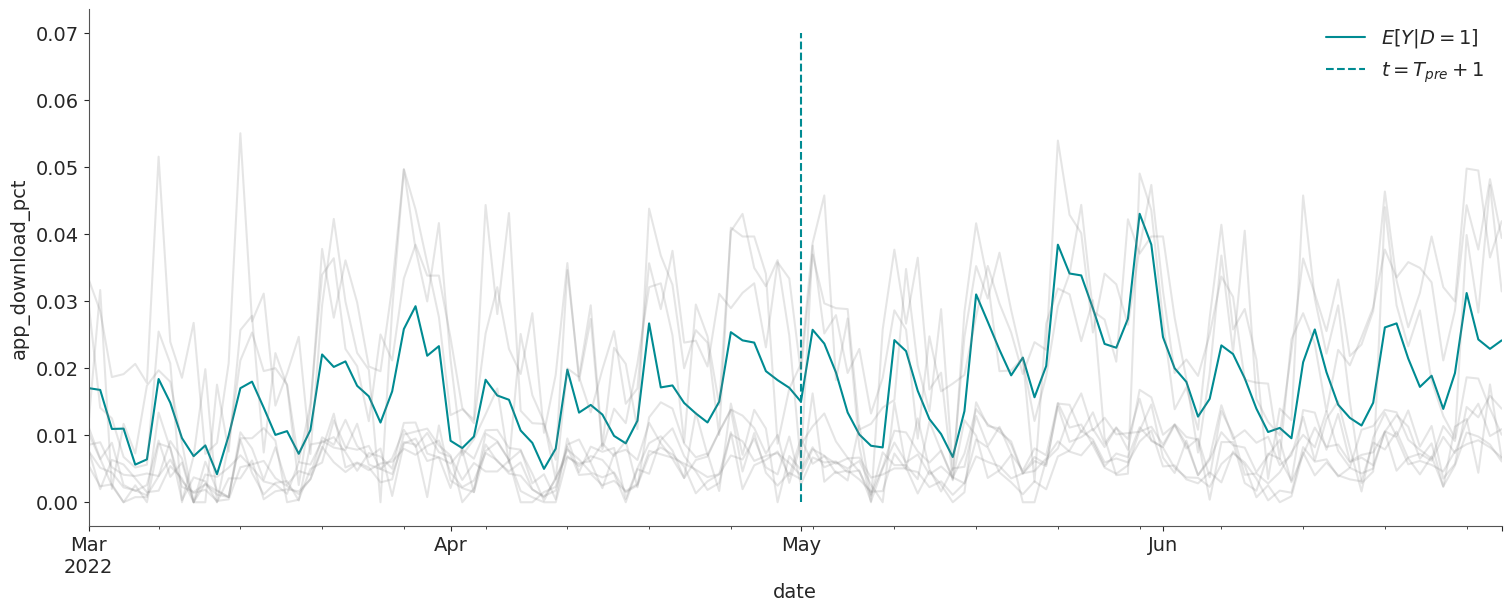

In [6]:
# Visualize data
np.random.seed(123)
df_plot = df_sc.pivot_table(
    index="date", columns="city",
    values="app_download_pct", aggfunc="mean"
)
ax = df_plot[treated_cities].mean(axis=1).plot(figsize=(15,6), label="$E[Y|D=1]$")
ax.vlines(tr_period, 0, 0.07, ls="dashed", label="$t=T_{pre}+1$")
ax.legend()
df_plot.drop(columns=treated_cities).sample(frac=0.2, axis=1).plot(color="0.5", alpha=0.2, legend=False, ax=ax)
plt.ylabel("app_download_pct")
plt.show()

In [7]:
def reshape_sc_data(df: pd.DataFrame,
                    geo_col: str, 
                    time_col: str,
                    y_col: str,
                    tr_geos: str,
                    tr_start: str):
    
    df_pivot = df.pivot_table(
        index=time_col, columns=geo_col, values=y_col, aggfunc="mean"
    )
    
    y_co = df_pivot.drop(columns=tr_geos)
    y_tr = df_pivot[tr_geos]
    
    y_pre_co = y_co[df_pivot.index < tr_start]
    y_pre_tr = y_tr[df_pivot.index < tr_start]
    
    y_post_co = y_co[df_pivot.index >= tr_start]
    y_post_tr = y_tr[df_pivot.index >= tr_start]
    
    return y_pre_co, y_pre_tr, y_post_co, y_post_tr

In [8]:
# Reshape data
y_pre_co, y_pre_tr, y_post_co, y_post_tr = reshape_sc_data(
    df=df_sc,
    geo_col="city",
    time_col="date",
    y_col="app_download_pct",
    tr_geos=treated_cities,
    tr_start=str(tr_period)
)
# Inspect data
display(
    y_pre_co.head(),
    y_pre_tr.head(),
    y_post_co.head(),
    y_post_tr.head()
)

city,ananindeua,aparecida_de_goiania,aracaju,belem,belford_roxo,belo_horizonte,brasilia,campinas,campo_grande,campos_dos_goytacazes,...,santo_andre,sao_bernardo_do_campo,sao_goncalo,sao_jose_dos_campos,sao_luis,serra,sorocaba,teresina,uberlandia,vila_velha
date,,,,,,,,,,,,,,,,,,,,,
2022-03-01,0.002035,0.008972,0.009664,0.003253,0.010092,0.007666,0.014510,0.026651,0.033297,0.008161,...,0.020860,0.024474,0.013475,0.023464,0.002509,0.008570,0.029770,0.007806,0.004104,0.012386
2022-03-02,0.000925,0.003323,0.006244,0.002921,0.004852,0.005137,0.011860,0.014061,0.028493,0.004663,...,0.021412,0.021768,0.014294,0.018581,0.000358,0.008942,0.014094,0.001951,0.004104,0.002163
2022-03-03,0.000370,0.000000,0.000000,0.001593,0.002523,0.004426,0.007077,0.023871,0.018668,0.005441,...,0.013814,0.011296,0.006555,0.023192,0.000538,0.005216,0.012512,0.006314,0.004246,0.002752
2022-03-04,0.000000,0.000000,0.001635,0.000266,0.006599,0.002213,0.008564,0.012590,0.019105,0.008355,...,0.011190,0.014473,0.009287,0.000000,0.000448,0.004099,0.006759,0.005625,0.004953,0.000000
2022-03-05,0.000925,0.000831,0.000000,0.001062,0.002329,0.001778,0.004363,0.009974,0.020633,0.006801,...,0.010913,0.011649,0.004825,0.015190,0.001075,0.003912,0.005177,0.003559,0.000849,0.000197


city,sao_paulo,porto_alegre,joao_pessoa
date,,,
2022-03-01,0.024733,0.004288,0.022039
2022-03-02,0.021789,0.008107,0.020344
2022-03-03,0.015545,0.004891,0.012352
2022-03-04,0.011705,0.002948,0.018285
2022-03-05,0.010067,0.006767,0.000000


city,ananindeua,aparecida_de_goiania,aracaju,belem,belford_roxo,belo_horizonte,brasilia,campinas,campo_grande,campos_dos_goytacazes,...,santo_andre,sao_bernardo_do_campo,sao_goncalo,sao_jose_dos_campos,sao_luis,serra,sorocaba,teresina,uberlandia,vila_velha
date,,,,,,,,,,,,,,,,,,,,,
2022-05-01,0.003886,0.001662,0.004906,0.001660,0.008152,0.003991,0.008079,0.019375,0.020633,0.013602,...,0.011190,0.019768,0.012200,0.027261,0.001523,0.004844,0.005609,0.009528,0.005661,0.006684
2022-05-02,0.001480,0.014954,0.005947,0.001859,0.016497,0.007903,0.012765,0.027468,0.038646,0.015933,...,0.046554,0.030710,0.014658,0.040417,0.000896,0.008197,0.038255,0.005740,0.006369,0.012189
2022-05-03,0.002591,0.010966,0.006096,0.001925,0.020767,0.006955,0.011149,0.030493,0.045742,0.008744,...,0.024175,0.022121,0.012382,0.025091,0.000986,0.005216,0.025168,0.006888,0.005661,0.012582
2022-05-04,0.000370,0.008308,0.001041,0.001328,0.007763,0.004347,0.008532,0.022400,0.018231,0.008161,...,0.023761,0.020591,0.010652,0.036077,0.000896,0.005962,0.027901,0.005740,0.005661,0.008650
2022-05-05,0.001295,0.007477,0.008920,0.001195,0.012810,0.004742,0.006981,0.019784,0.027402,0.012630,...,0.024589,0.009060,0.008194,0.008951,0.000538,0.005030,0.019271,0.006543,0.004246,0.006291


city,sao_paulo,porto_alegre,joao_pessoa
date,,,
2022-05-01,0.025852,0.007151,0.012002
2022-05-02,0.038626,0.011859,0.026667
2022-05-03,0.035158,0.010330,0.025489
2022-05-04,0.027158,0.008828,0.022057
2022-05-05,0.021637,0.005278,0.013243


In [9]:
# Get all control and treatment y
y_co = pd.concat([y_pre_co, y_post_co])
y_tr = pd.concat([y_pre_tr, y_post_tr])
# Inspect results
display(
    y_co, y_tr
)

city,ananindeua,aparecida_de_goiania,aracaju,belem,belford_roxo,belo_horizonte,brasilia,campinas,campo_grande,campos_dos_goytacazes,...,santo_andre,sao_bernardo_do_campo,sao_goncalo,sao_jose_dos_campos,sao_luis,serra,sorocaba,teresina,uberlandia,vila_velha
date,,,,,,,,,,,,,,,,,,,,,
2022-03-01,0.002035,0.008972,0.009664,0.003253,0.010092,0.007666,0.014510,0.026651,0.033297,0.008161,...,0.020860,0.024474,0.013475,0.023464,0.002509,0.008570,0.029770,0.007806,0.004104,0.012386
2022-03-02,0.000925,0.003323,0.006244,0.002921,0.004852,0.005137,0.011860,0.014061,0.028493,0.004663,...,0.021412,0.021768,0.014294,0.018581,0.000358,0.008942,0.014094,0.001951,0.004104,0.002163
2022-03-03,0.000370,0.000000,0.000000,0.001593,0.002523,0.004426,0.007077,0.023871,0.018668,0.005441,...,0.013814,0.011296,0.006555,0.023192,0.000538,0.005216,0.012512,0.006314,0.004246,0.002752
2022-03-04,0.000000,0.000000,0.001635,0.000266,0.006599,0.002213,0.008564,0.012590,0.019105,0.008355,...,0.011190,0.014473,0.009287,0.000000,0.000448,0.004099,0.006759,0.005625,0.004953,0.000000
2022-03-05,0.000925,0.000831,0.000000,0.001062,0.002329,0.001778,0.004363,0.009974,0.020633,0.006801,...,0.010913,0.011649,0.004825,0.015190,0.001075,0.003912,0.005177,0.003559,0.000849,0.000197
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-06-26,0.001480,0.007311,0.007434,0.001859,0.017468,0.007626,0.010018,0.031392,0.009607,0.015933,...,0.030253,0.038359,0.015478,0.026447,0.001523,0.009129,0.028620,0.007347,0.006227,0.010026
2022-06-27,0.004626,0.014456,0.013529,0.003585,0.020379,0.008654,0.017257,0.041366,0.039847,0.021568,...,0.047521,0.052008,0.023854,0.049369,0.000717,0.018630,0.044296,0.012053,0.013303,0.010026
2022-06-28,0.003146,0.013126,0.010110,0.004315,0.023678,0.009246,0.013767,0.047824,0.028275,0.023706,...,0.058849,0.042830,0.018118,0.048284,0.001165,0.018444,0.037680,0.014694,0.011888,0.013958


city,sao_paulo,porto_alegre,joao_pessoa
date,,,
2022-03-01,0.024733,0.004288,0.022039
2022-03-02,0.021789,0.008107,0.020344
2022-03-03,0.015545,0.004891,0.012352
2022-03-04,0.011705,0.002948,0.018285
2022-03-05,0.010067,0.006767,0.000000
...,...,...,...
2022-06-26,0.033372,0.011021,0.013384
2022-06-27,0.045628,0.016732,0.031237
2022-06-28,0.043631,0.012706,0.016492


## Frequentist SC

In [10]:
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.utils.validation import (
    check_X_y, check_array,
    check_is_fitted
)
import cvxpy as cp

class SyntheticControl(BaseEstimator, RegressorMixin):

    def __init__(self,):
        pass

    def fit(self, y_pre_co, y_pre_tr):

        y_pre_co, y_pre_tr = check_X_y(y_pre_co, y_pre_tr)
    
        w = cp.Variable(y_pre_co.shape[1])
        
        objective = cp.Minimize(cp.sum_squares(y_pre_co@w - y_pre_tr))
        constraints = [cp.sum(w) == 1, w >= 0]
        
        problem = cp.Problem(objective, constraints)
        
        self.loss_ = problem.solve(verbose=False)
        self.w_ = w.value
        
        self.is_fitted_ = True
        return self
        
        
    def predict(self, y_co):

        check_is_fitted(self)
        y_co = check_array(y_co)
        
        return y_co @ self.w_

In [11]:
# Instanciate SC model with convex implementation
model = SyntheticControl()
model.fit(
    y_pre_co,
    y_pre_tr.mean(axis=1)
)

# Extrac the weights
model.w_.round(3)

array([-0.   , -0.   , -0.   , -0.   , -0.   , -0.   ,  0.076,  0.037,
        0.083,  0.01 , -0.   , -0.   , -0.   , -0.   , -0.   , -0.   ,
        0.061,  0.123,  0.008,  0.074, -0.   ,  0.   , -0.   , -0.   ,
       -0.   , -0.   , -0.   , -0.   , -0.   ,  0.   , -0.   ,  0.092,
       -0.   , -0.   ,  0.   ,  0.046,  0.089,  0.   ,  0.067,  0.061,
        0.   , -0.   , -0.   ,  0.088,  0.   ,  0.086, -0.   ])

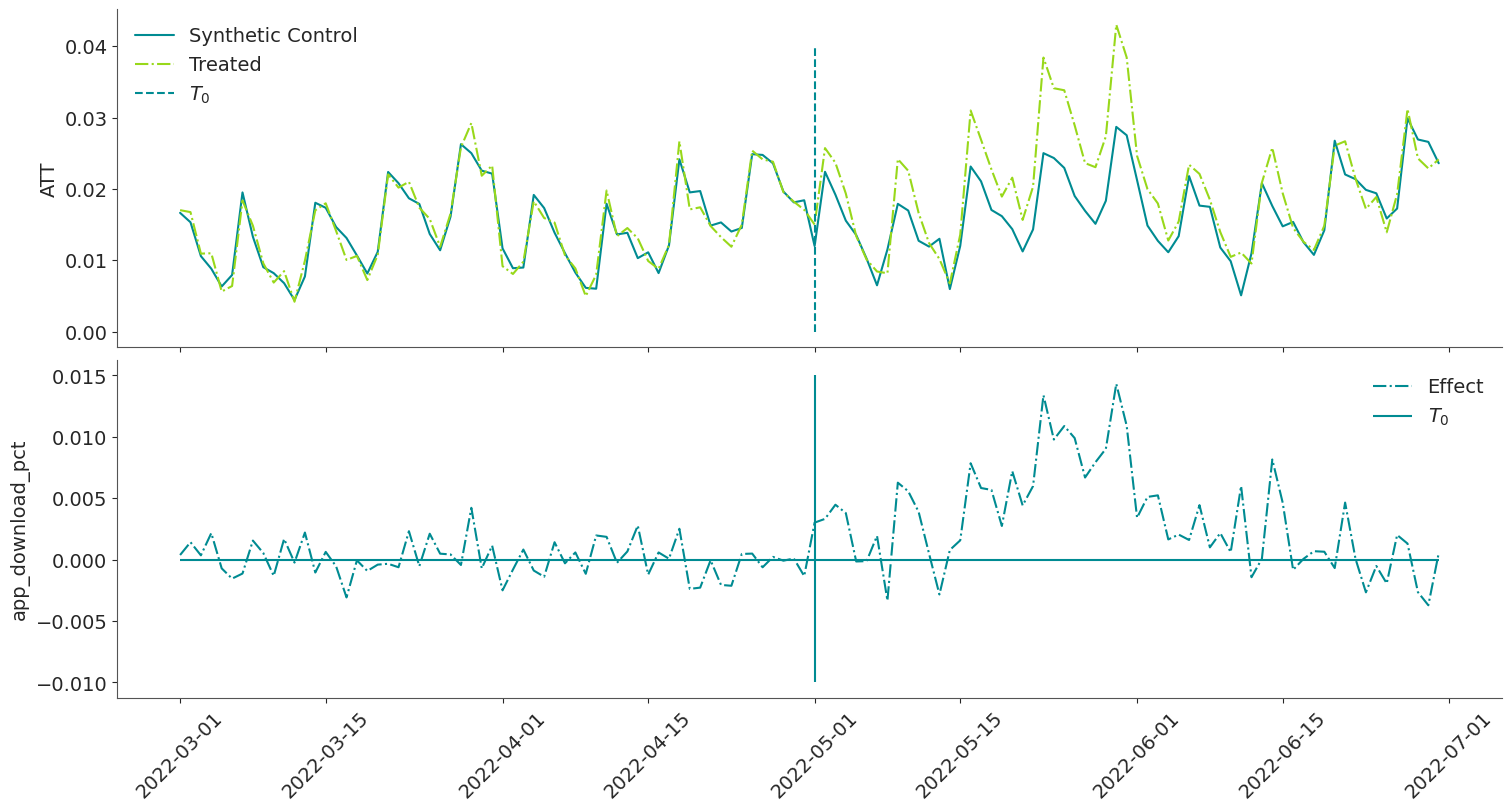

In [12]:
# Inspect estimations
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15,8), sharex=True)

ax1.plot(y_co.index, model.predict(y_co), label="Synthetic Control")
ax1.plot(y_tr.mean(axis=1), label="Treated", ls="-.")
ax1.vlines(pd.to_datetime("2022-05-01"), 0, 0.04, ls="dashed", label="$T_0$")
ax1.legend()
ax1.set_ylabel("ATT")

ax2.plot(y_co.index, y_tr.mean(axis=1) - model.predict(y_co), label="Effect", ls="-.")
ax2.hlines(0, y_co.index.min(), y_co.index.max())
ax2.vlines(pd.to_datetime("2022-05-01"), -0.01, 0.015, label="$T_0$")
ax2.legend()
ax2.set_ylabel("app_download_pct")

plt.xticks(rotation=45);

## Bayesian SC


	Target std: 0.005891848995726183



/home/gus-cunha/.pyenv/versions/3.12.3/envs/bayesian_causal_inference_study/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27 () missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


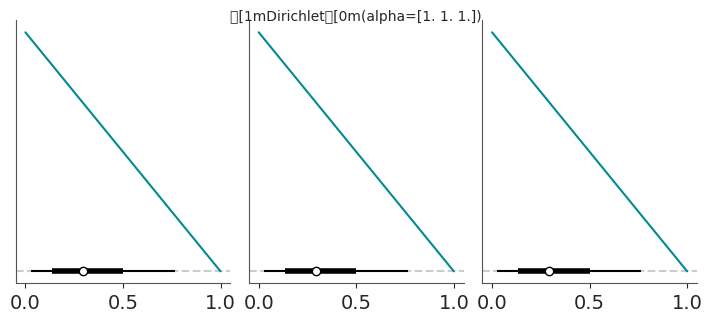

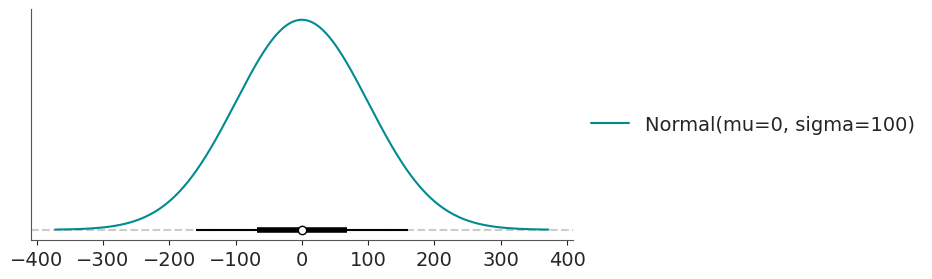

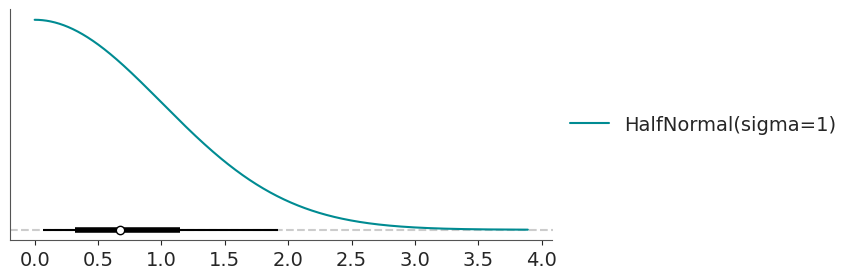

In [13]:
##########################
######### PRIORS #########

# Insp
print(f"\n\tTarget std: {y_pre_tr.mean(axis=1).std(ddof=1)}\n")

pz.Dirichlet(alpha=[1, 1, 1]).plot_pdf(pointinterval=True,figsize=(7, 3))
plt.show()
pz.Normal(mu=0, sigma=100).plot_pdf(pointinterval=True,figsize=(7, 3))
plt.show()
pz.HalfNormal(sigma=1).plot_pdf(pointinterval=True,figsize=(7, 3))
plt.show()

### Understanding the Dirichlet distribution

Quick visual detour before fitting the SC weights: the plot below draws samples from a 5-component Dirichlet($\alpha$) and shows them on a radar chart (center = 0, outer edge = 1). Each thin line is one draw; the thick line is the mean. It compares the three regimes the $\alpha$ concentration parameter produces:

- **$\alpha < 1$**: mass pushed toward the simplex corners -> sparse, spiky draws (one weight near 1, the rest near 0)
- **$\alpha = 1$**: uniform over the simplex -> irregular, unpredictable polygons (this is what `pz.Dirichlet(alpha=[1, 1, 1])` above looks like, generalized to 5 dims)
- **$\alpha > 1$**: mass pulled toward the center -> tight, near-regular pentagons with roughly equal shares on every axis

/tmp/ipykernel_9493/3229581551.py:77: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0.03, 1, 0.92])


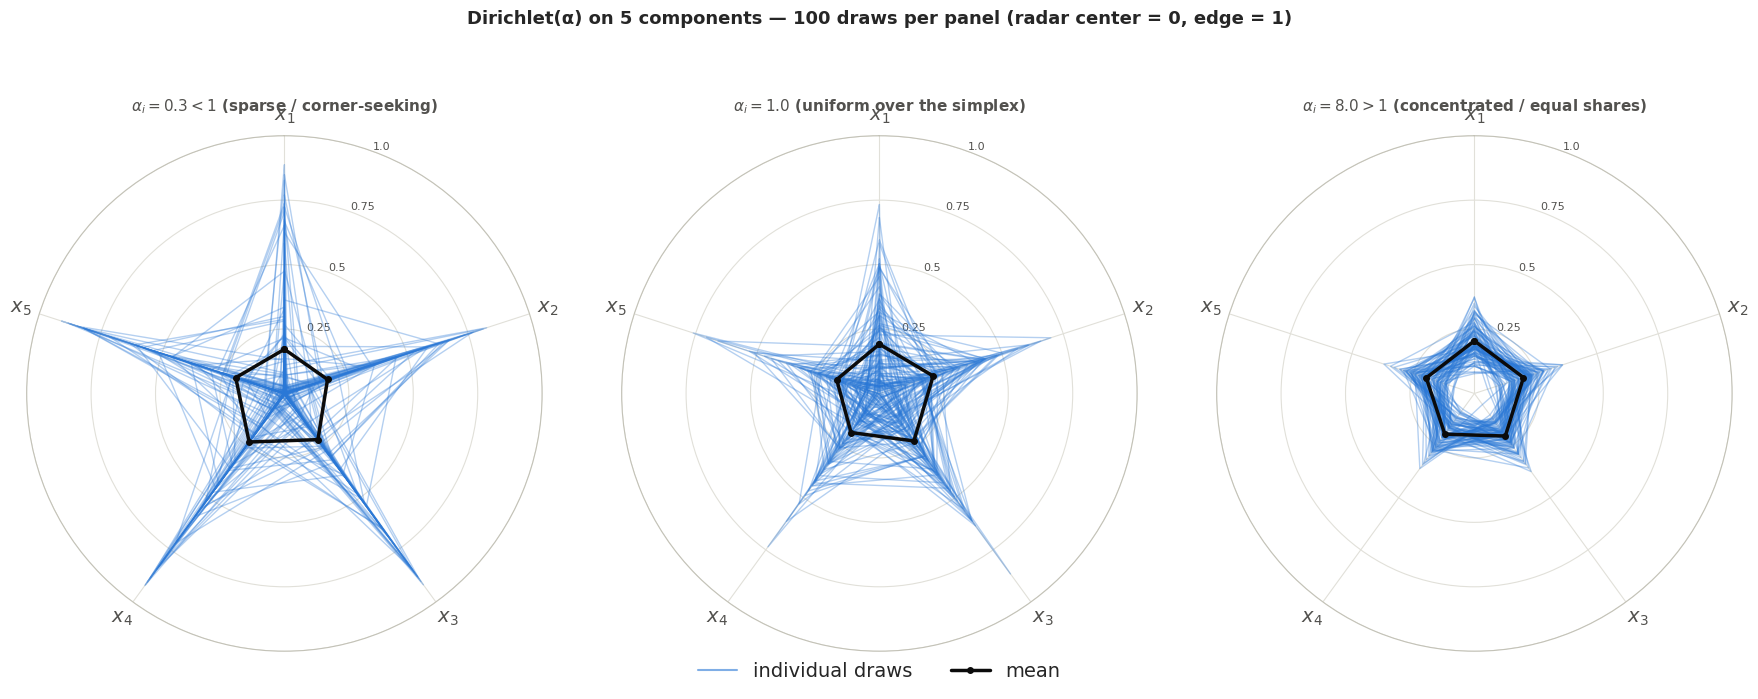

In [3]:
# Understanding the Dirichlet distribution: radar view of samples
#
# Each axis is one of the 5 simplex components (x1..x5). Center of the radar = 0,
# outer edge = 1. Each thin line is one draw from Dirichlet(alpha); the thick
# line is the mean across draws. Since sum(x) = 1 for every draw, watch how the
# *shape* of the polygon (not any single axis) changes with alpha:
#   - alpha < 1 -> mass pushed to the simplex corners: spiky, sparse draws
#     (one component near 1, the rest near 0)
#   - alpha = 1 -> uniform over the simplex: irregular, unpredictable polygons
#   - alpha > 1 -> mass pulled to the center (equal shares): small, tight,
#     near-regular pentagons hugging ~1/5 on every axis

# dataviz reference palette: series-1 blue for individual draws, primary ink for the mean
DRAW_COLOR = "#2a78d6"
MEAN_COLOR = "#0b0b0b"
GRID_COLOR = "#e1e0d9"
AXIS_COLOR = "#c3c2b7"
LABEL_COLOR = "#52514e"

K = 5  # number of Dirichlet components
N_SAMPLES = 100
SEED = 5

alpha_sets = {
    r"$\alpha_i = 0.3 < 1$ (sparse / corner-seeking)": np.full(K, 0.3),
    r"$\alpha_i = 1.0$ (uniform over the simplex)": np.full(K, 1.0),
    r"$\alpha_i = 8.0 > 1$ (concentrated / equal shares)": np.full(K, 8.0),
}

angles = np.linspace(0, 2 * np.pi, K, endpoint=False).tolist()
angles += angles[:1]

rng = np.random.default_rng(SEED)

fig, axes = plt.subplots(
    1, 3, figsize=(18, 6.5), subplot_kw=dict(polar=True)
)

for ax, (title, alpha) in zip(axes, alpha_sets.items()):
    samples = rng.dirichlet(alpha, size=N_SAMPLES)

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([f"$x_{i+1}$" for i in range(K)], color=LABEL_COLOR)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(["0.25", "0.5", "0.75", "1.0"], color=LABEL_COLOR, fontsize=8)
    ax.set_rlabel_position(20)
    ax.spines["polar"].set_color(AXIS_COLOR)
    ax.grid(color=GRID_COLOR)

    for s in samples:
        vals = s.tolist() + s[:1].tolist()
        ax.plot(angles, vals, linewidth=1.0, color=DRAW_COLOR, alpha=0.35)

    mean_vals = samples.mean(axis=0)
    mean_vals = mean_vals.tolist() + mean_vals[:1].tolist()
    ax.plot(
        angles, mean_vals, linewidth=2.5, color=MEAN_COLOR,
        marker="o", markersize=4, label="mean",
    )

    ax.set_title(title, pad=18, color=LABEL_COLOR, fontsize=11)

# One shared legend (2 series: individual draws vs. mean)
handles = [
    plt.Line2D([0], [0], color=DRAW_COLOR, alpha=0.6, lw=1.5, label="individual draws"),
    plt.Line2D([0], [0], color=MEAN_COLOR, lw=2.5, marker="o", markersize=4, label="mean"),
]
fig.legend(handles=handles, loc="lower center", ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.02))

fig.suptitle(
    f"Dirichlet(α) on {K} components — {N_SAMPLES} draws per panel (radar center = 0, edge = 1)",
    fontsize=13, y=1.04,
)
plt.tight_layout(rect=[0, 0.03, 1, 0.92])
plt.show()


In [ ]:
############################
######### BAYESIAN #########

# Define coordinates to track pre-treatment weights
coords = {
    "sc_donor_unit": y_pre_co.columns.tolist(),
    "sc_donor_time": np.arange(y_pre_co.shape[0]),
}

# `coords` doesn't touch the math at all — it's pure readability feature.
# Nothing happens until a variable references one of those dim names via dims=
with pm.Model(coords=coords) as model_sc:
    # Create a data container to estimate counterfactuals
    # At first as a constant data [idata.constant_data].
    # But it's mutable: the moment I call pm.set_data(...), 
    # the old values are gone from the live model (overwritten in-place);
    # only the copy already stored in idata_sc.constant_data from the first sampling run preserves it.
    # So the pattern for your synthetic control is: 
    #   sample once with y_pre_co → 
    #   snapshot lands in idata_sc → 
    #   swap to y_post_co via set_data → 
    #   posterior-predictive-sample again into a separate idata_post for the counterfactual.
    donor_matrix = pm.Data(
        name="donor_matrix",
        value=y_pre_co.values,
        dims=("sc_donor_time", "sc_donor_unit")  # dimensions on `value` param
    )
    # Priors
    # Dirichlet: 0 <= p_i <= 1, all summing to 1
    p = pm.Dirichlet(
        name="p",
        a=np.ones(shape=len(coords["sc_donor_unit"])),  # shape - one weight per sc_donor_unit
        dims="sc_donor_unit"  # for inference data labelling, doesn't change the sampling
    )
    σ = pm.HalfNormal(
        name="σ", sigma=1
    )
    # Likelihood
    # math.dot to get shape (n_obs,) - sums over donors - not a element wise product
    μ = pm.math.dot(donor_matrix, p)
    y_pred = pm.Normal(
        name="y_pred",
        mu=μ,
        sigma=σ,
        observed=y_pre_tr.mean(axis=1).values,
        # for inference data labelling, doesn't change the sampling
        # one prediction per time point
        dims="sc_donor_time"
    )
    # MCMC sampling
    idata_sc = pm.sample(
        nuts_sampler="nutpie",
        draws=4_000,
        tune=4_000,
        chains=N_CHAINS,
        cores=N_CHAINS,
        random_seed=SEED,
        progressbar=True,
        discard_tuned_samples=True,
        return_inferencedata=True,
        target_accept=0.99,  # up from default 0.8; try 0.99 if 0.95 doesn't clear it
    )
    pm.compute_log_likelihood(
        idata=idata_sc, extend_inferencedata=True
    )

# Save a checkpoint
idata_sc.to_netcdf(
    filepath=os.path.join(PYMC_MODELS_PATH, "model_sc.nc")
)

# Inspect idata
idata_sc

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p, σ]


Output()

Sampling 4 chains for 4_000 tune and 4_000 draw iterations (16_000 + 16_000 draws total) took 67 seconds.


Output()

<xarray.DataTree>
Group: /
├── Group: /posterior
│       Dimensions:        (chain: 4, draw: 4000, sc_donor_unit: 47)
│       Coordinates:
│         * chain          (chain) int64 32B 0 1 2 3
│         * draw           (draw) int64 32kB 0 1 2 3 4 5 ... 3995 3996 3997 3998 3999
│         * sc_donor_unit  (sc_donor_unit) <U23 4kB 'ananindeua' ... 'vila_velha'
│       Data variables:
│           p              (chain, draw, sc_donor_unit) float64 6MB 0.01641 ... 0.01826
│           σ              (chain, draw) float64 128kB 0.001836 0.00216 ... 0.001845
│       Attributes:
│           created_at:                 2026-07-22T19:34:19.798161+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.1.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.0.1
│           sample_dims:                ['chain', 'draw']
│           sampling_time:              66.87685060501099
│           tuning_steps:               4000
├── Group: /sample_stats
│       Dimensions:                (chain: 4, draw: 4000)
│       Coordinates:
│         * chain                  (chain) int64 32B 0 1 2 3
│         * draw                   (draw) int64 32kB 0 1 2 3 4 ... 3996 3997 3998 3999
│       Data variables: (12/18)
│           diverging              (chain, draw) bool 16kB False False ... False False
│           energy                 (chain, draw) float64 128kB -194.6 -182.4 ... -187.2
│           perf_counter_start     (chain, draw) float64 128kB 2.762e+04 ... 2.765e+04
│           process_time_diff      (chain, draw) float64 128kB 0.007624 ... 0.006354
│           lp                     (chain, draw) float64 128kB 216.4 208.6 ... 207.4
│           index_in_trajectory    (chain, draw) int64 128kB -82 -31 29 ... -82 -106 77
│           ...                     ...
│           acceptance_rate        (chain, draw) float64 128kB 0.9838 0.9951 ... 0.9983
│           smallest_eigval        (chain, draw) float64 128kB nan nan nan ... nan nan
│           step_size_bar          (chain, draw) float64 128kB 0.0357 0.0357 ... 0.03479
│           step_size              (chain, draw) float64 128kB 0.034 0.034 ... 0.03417
│           max_energy_error       (chain, draw) float64 128kB 0.1145 ... -0.03499
│           divergences            (chain, draw) int64 128kB 0 0 0 0 0 0 ... 0 0 0 0 0 0
│       Attributes:
│           created_at:                 2026-07-22T19:34:19.826320+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.1.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.0.1
│           sample_dims:                ['chain', 'draw']
│           sampling_time:              66.87685060501099
│           tuning_steps:               4000
├── Group: /observed_data
│       Dimensions:        (sc_donor_time: 61)
│       Coordinates:
│         * sc_donor_time  (sc_donor_time) int64 488B 0 1 2 3 4 5 ... 55 56 57 58 59 60
│       Data variables:
│           y_pred         (sc_donor_time) float64 488B 0.01702 0.01675 ... 0.01707
│       Attributes:
│           created_at:                 2026-07-22T19:34:19.832027+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.1.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.0.1
│           sample_dims:                []
├── Group: /constant_data
│       Dimensions:        (sc_donor_time: 61, sc_donor_unit: 47)
│       Coordinates:
│         * sc_donor_time  (sc_donor_time) int64 488B 0 1 2 3 4 5 ... 55 56 57 58 59 60
│         * sc_donor_unit  (sc_donor_unit) <U23 4kB 'ananindeua' ... 'vila_velha'
│       Data variables:
│           donor_matrix   (sc_donor_time, sc_donor_unit) float64 23kB 0.002035 ... 0...
│       Attributes:
│           created_at:             

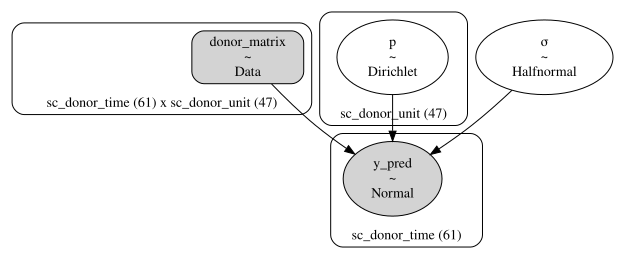

In [68]:
# plot graph
model_sc.to_graphviz()

In [69]:
# Get diverging draws
#   idata_sc.sample_stats["diverging"] dimensions -> (chain: 4; draw: 4000)
diverging_mask = idata_sc.sample_stats["diverging"].values.reshape(-1)
# Print report
print(f"Percentage of divergent draws: {diverging_mask.mean() * 100:.2f}% [threshold < 0.1%]")

# Get posterior for param `p`, stacking chain and draws
#   data_sc.posterior["p"]                          -> dimensions (chain: 4; draw: 4000; sc_donor_unit: 47)
#   stacking on chain and draws (same order as diverging)
#   ... after .stack(sample=("chain", "draw"))      -> dimensions (sc_donor_unit: 47; sample: 16000)
#   ... after .transpose("sample", ...)             -> dimensions (sample: 16000; sc_donor_unit: 47)
flatten_param = idata_sc.posterior["p"].stack(sample=("chain", "draw")).transpose("sample", ...).values

# Get healthy params
diverging_param_value = flatten_param[diverging_mask]       # shape (n_divergent_draws, sc_donor_unit) — only the rows from divergent draws, still one column per donor.
non_diverging_param_value = flatten_param[~diverging_mask]  # shape (n_ok_draws, sc_donor_unit)

# Get the smallest donor weight *within* each divergent draw -> shape (n_div,)
per_draw_min_diverging = diverging_param_value.min(axis=1)
# Get the same but for accepted draws - shape (n_ok,)
per_draw_min_non_diverging  = non_diverging_param_value.min(axis=1)
# Print report
# axis=1 collapses across donors within each draw, giving you one "how close to a corner was this specific draw" number per draw, 
# then you compare the typical value of that number between groups.
# If the median is systematically smaller for divergent draws, 
# that's much better evidence that divergences correspond to draws sitting nearer the simplex boundary — not just a coincidental single extreme value.
print("median per-draw min weight, divergent:    ", np.median(per_draw_min_diverging))
print("median per-draw min weight, non-divergent:", np.median(per_draw_min_non_diverging))

Percentage of divergent draws: 0.00% [threshold < 0.1%]
median per-draw min weight, divergent:     nan
median per-draw min weight, non-divergent: 0.00024574645374452993


/home/gus-cunha/.pyenv/versions/3.12.3/envs/bayesian_causal_inference_study/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/gus-cunha/.pyenv/versions/3.12.3/envs/bayesian_causal_inference_study/lib/python3.12/site-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [70]:
# Inspect summary
# R hat
#   compute the variance between chains with the variance within chains
#   Ideally = 1, okay if < 1.01
# ESS (Effective Sample Size)
#   Less than the draws due to autocorrelation
#   At least 400 (100 ESS per chain) -> the higher the better
# MCSE - Monte Carlo Standard Error
#   Error introduced on MC posterior due to 
#   finite sampling and samples not being truely independent
#   It impact the precision of results
#   The pass criteria to check:
#       mcse_mean / sd (from the same table) below ~5–10%
#       If those all pass (R hat, ESS and MCSE), a U shape MCSE plot is fine as-is
#       the shape is just the normal signature of tail quantiles being harder to pin down.
summary = az.summary(
    data=idata_sc,
    var_names=None, filter_vars=None,
    group='posterior', coords=None, sample_dims=None,
    kind='all', fmt='wide', ci_prob=0.95, ci_kind="hdi",
    round_to='auto', skipna=False
)

# Relative MCSE: how big is the sampling error compared to the posterior's own spread?
#   mcse_mean_pct = MCSE of the posterior mean, as a % of the posterior SD.
#       Rule of thumb: < 5–10% is fine; 
#       higher means you'd need more draws to trust the reported mean/HDI to that many significant digits.
#   mcse_sd_pct = same idea for the SD estimate.
summary["mcse_mean_pct"] = summary["mcse_mean"].astype(float) / summary["sd"].astype(float)
summary["mcse_sd_pct"]   = summary["mcse_sd"].astype(float)   / summary["sd"].astype(float)
summary: pd.DataFrame = summary.astype("float")
summary

,mean,sd,hdi95_lb,hdi95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd,mcse_mean_pct,mcse_sd_pct
p[ananindeua],0.010700,0.010500,0.00029,0.0390,20582.0,10068.0,1.0,0.000067,8.700000e-05,0.006381,0.008286
p[aparecida_de_goiania],0.009600,0.009400,0.00025,0.0350,15205.0,8111.0,1.0,0.000062,7.900000e-05,0.006596,0.008404
p[aracaju],0.012800,0.012400,0.00034,0.0460,17658.0,8119.0,1.0,0.000077,9.600000e-05,0.006210,0.007742
p[belem],0.010300,0.010100,0.00027,0.0370,17453.0,8986.0,1.0,0.000065,8.500000e-05,0.006436,0.008416
p[belford_roxo],0.014600,0.013700,0.00039,0.0510,17900.0,8991.0,1.0,0.000088,1.000000e-04,0.006423,0.007299
p[belo_horizonte],0.012600,0.012100,0.00036,0.0440,19034.0,9437.0,1.0,0.000079,1.000000e-04,0.006529,0.008264
p[brasilia],0.021000,0.019600,0.00061,0.0720,18211.0,8682.0,1.0,0.000120,1.500000e-04,0.006122,0.007653
p[campinas],0.039300,0.030800,0.00140,0.1100,13898.0,7221.0,1.0,0.000210,1.900000e-04,0.006818,0.006169
p[campo_grande],0.088100,0.023500,0.04100,0.1300,19491.0,10739.0,1.0,0.000170,1.200000e-04,0.007234,0.005106
p[campos_dos_goytacazes],0.016800,0.015700,0.00042,0.0580,18286.0,8886.0,1.0,0.000096,1.100000e-04,0.006115,0.007006


In [71]:
# Inspect problematic donors
problematic_params = summary[
    (
        summary.r_hat > 1.01
    ) | (
        summary.ess_bulk < N_CHAINS*100
    ) | (
        summary.ess_tail < N_CHAINS*100
    ) | (
        summary.mcse_mean_pct > 0.05
    )
]
problematic_params

,mean,sd,hdi95_lb,hdi95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd,mcse_mean_pct,mcse_sd_pct


In [72]:
# Get posterior predictive
with model_sc:
    pm.sample_posterior_predictive(
        trace=idata_sc,
        random_seed=SEED, progressbar=True,
        return_inferencedata=True, extend_inferencedata=True
)

# Save a checkpoint
idata_sc.to_netcdf(
    filepath=os.path.join(PYMC_MODELS_PATH, "model_sc.nc")
)

Sampling: [y_pred]


Output()

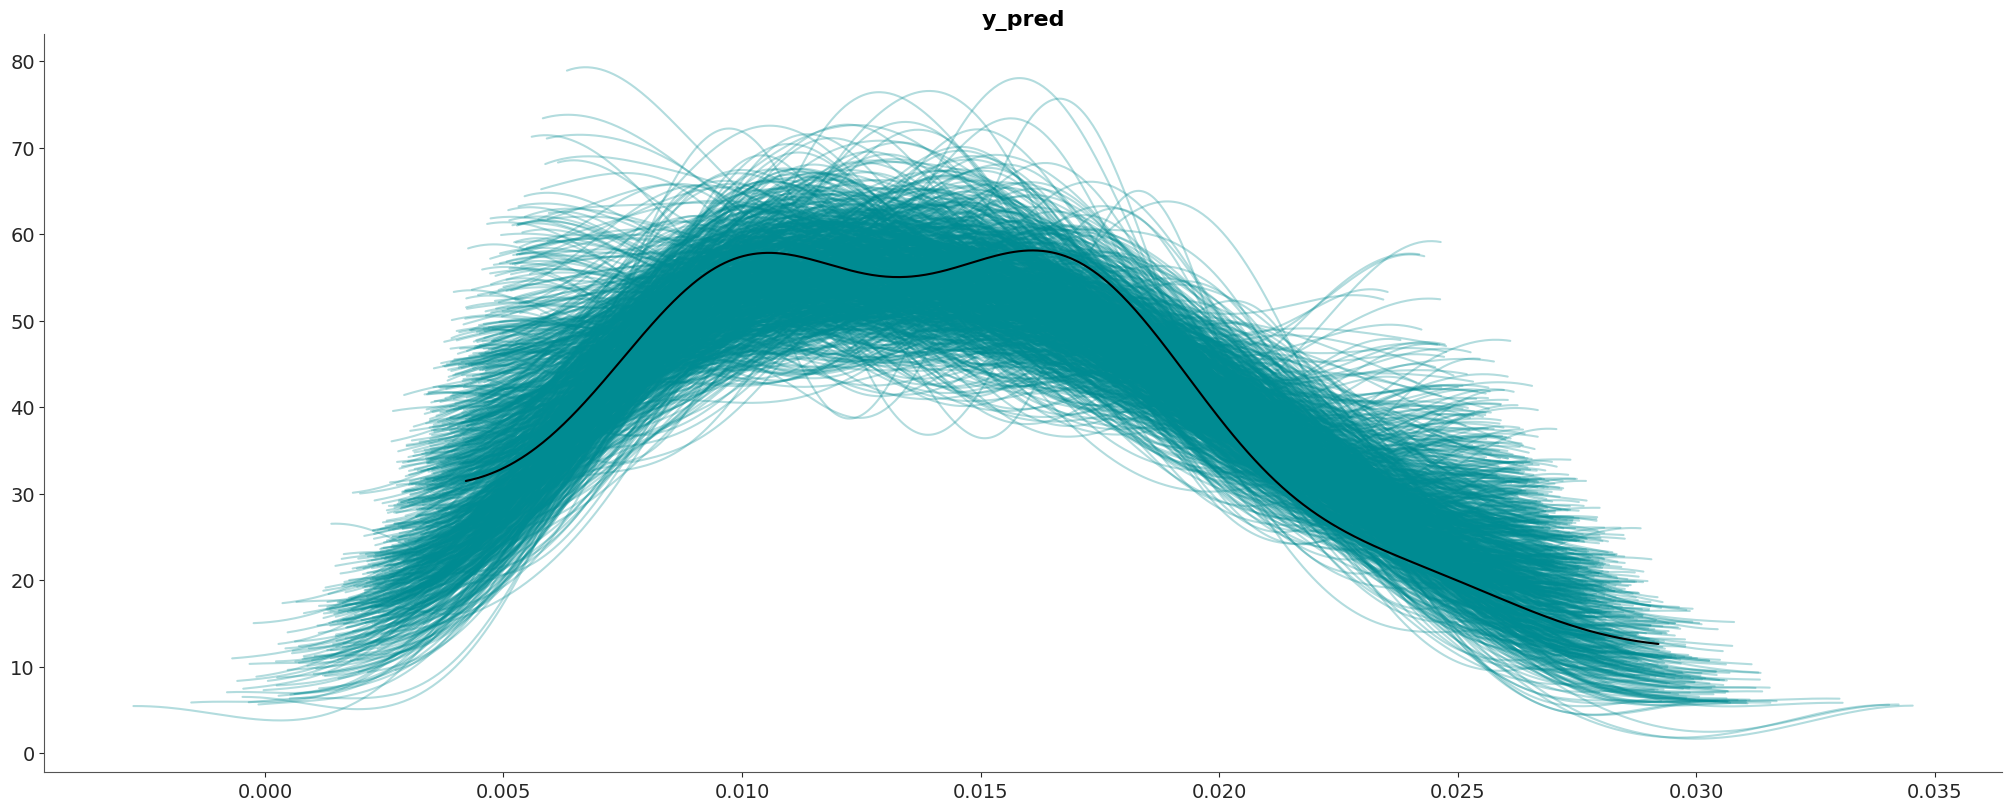

In [73]:
# Inspect posterior predictive
# Does the fitted combination reproduce the treated unit's pre-period trend?
az.plot_ppc_dist(
    dt=idata_sc, 
    var_names=None, filter_vars=None,
    group='posterior_predictive', coords=None, sample_dims=None,
    kind='kde', num_samples=1_000, stats=None,
    figure_kwargs={"figsize": (20, 8)},
);

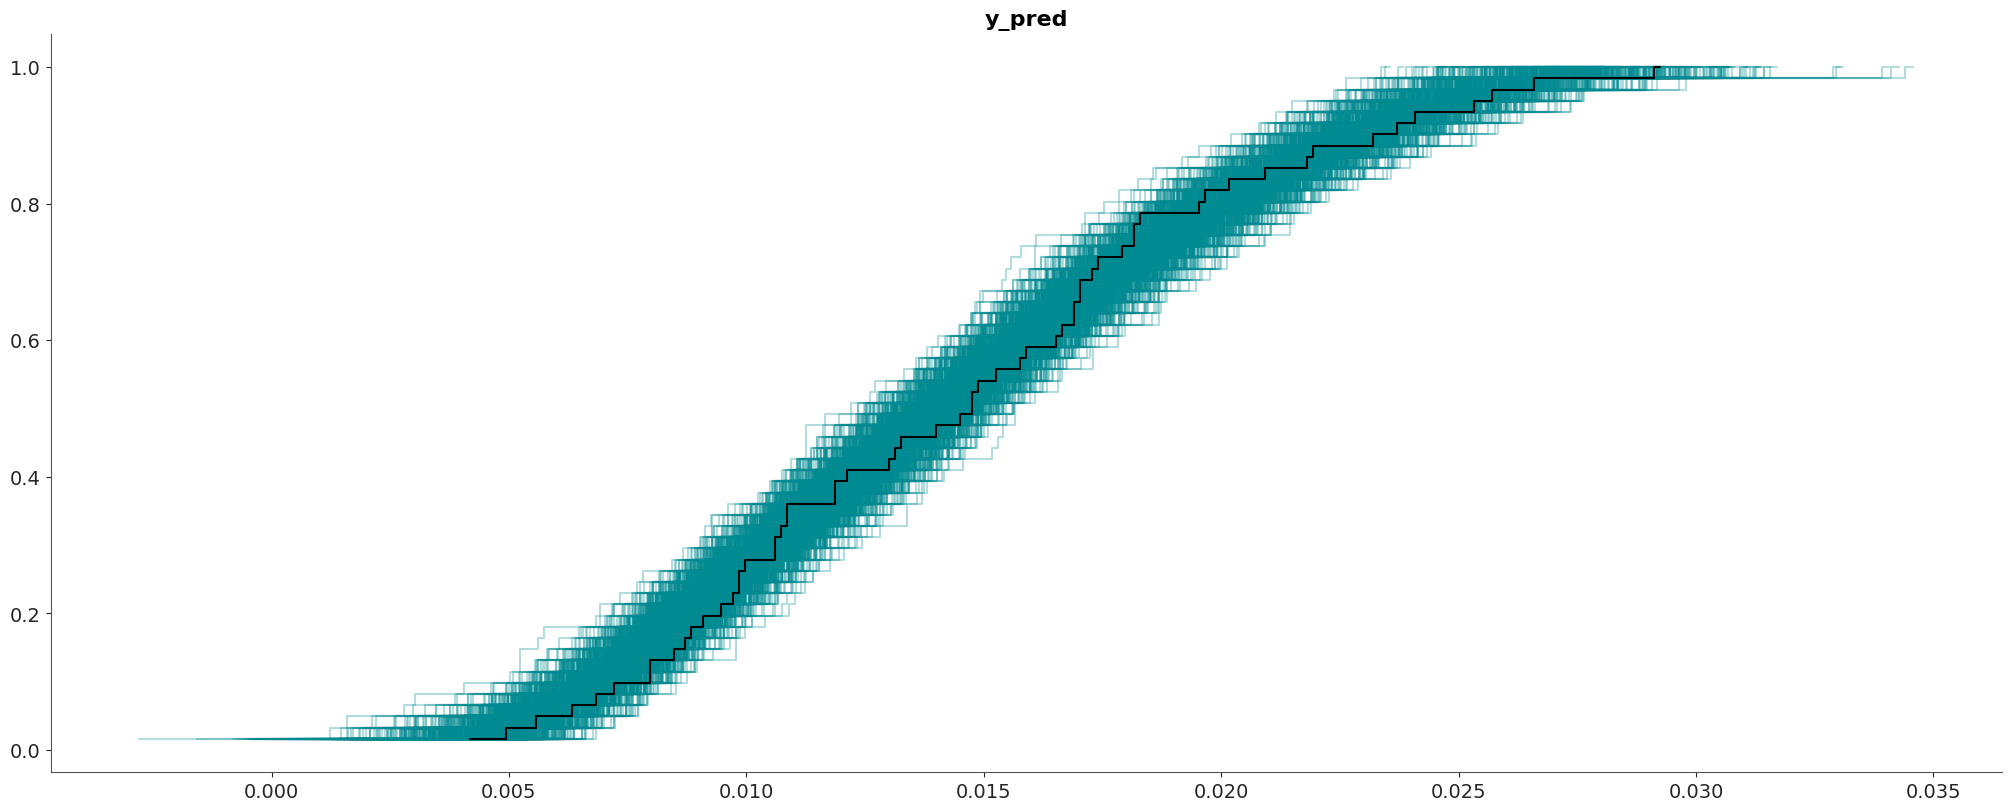

In [74]:
# Inspect posterior predictive
# Does the fitted combination reproduce the treated unit's pre-period trend?
az.plot_ppc_dist(
    dt=idata_sc, 
    var_names=None, filter_vars=None,
    group='posterior_predictive', coords=None, sample_dims=None,
    kind='ecdf', num_samples=1_000, stats=None,
    figure_kwargs={"figsize": (20, 8)},
);

In [83]:
# Counterfactual: swap donor_matrix to the post-period donors ---
# This overwrites the live model's data (per your own comment in the model cell) —
# the pre-period snapshot is already safe in idata_sc.constant_data.
with model_sc:
    pm.set_data(
        new_data={
            "donor_matrix": y_co.values
        },
        coords={  # dimensions on `value` param
            "sc_donor_time": np.arange(y_co.shape[0]),
            "sc_donor_unit": y_co.columns.tolist(),
        },
    )
    # Get predictions
    pm.sample_posterior_predictive(
        trace=idata_sc,
        var_names=["y_pred"],
        predictions=True,  # store predictions in a separate predictions group.
        random_seed=SEED, progressbar=True,
        return_inferencedata=True, extend_inferencedata=True
    )

# Save a checkpoint
idata_sc.to_netcdf(
    filepath=os.path.join(PYMC_MODELS_PATH, "model_sc.nc")
)


Sampling: [y_pred]


Output()

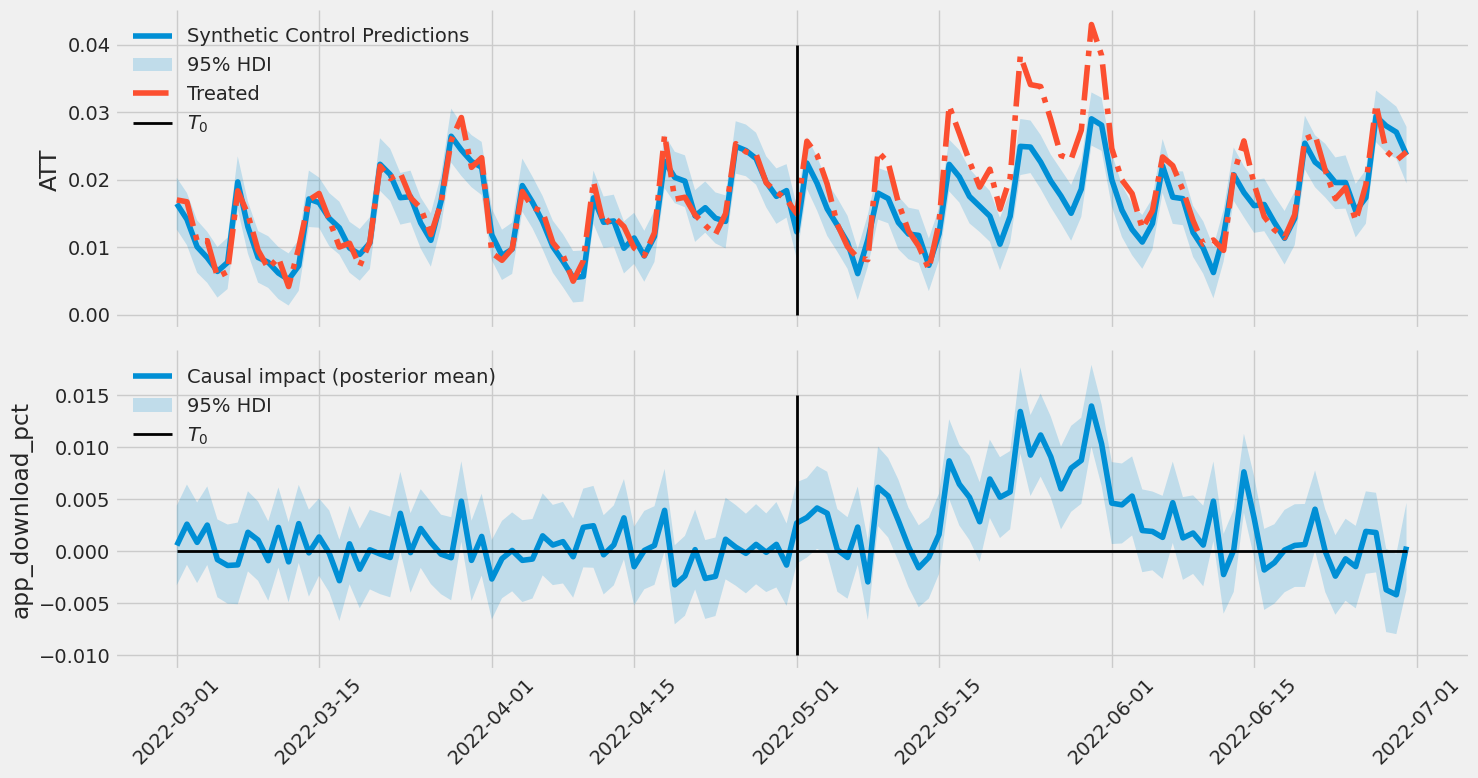

In [113]:
##################################################
######### PLOT: SYNTHETIC CONTROL vs TREATED ####
##################################################
# Define highest density interval (HDI)
hdi_prob = 0.95

# Get predictions for pre and pos period (as donor_matrix in sample_posterior_predictive was pre + pos)
pred_full = idata_sc.predictions["y_pred"]  # dims: (chain: 4; draw: 4000; sc_donor_time: 122) -> pre + post
# Average per chain and draws -> dims: (sc_donor_time: 122)
sc_mean = pred_full.mean(dim=("chain", "draw")).values
# Compute the highest density interval (HDI) given a probability.
# The HDI is the shortest interval that contains the specified probability mass.
hdi_full = az.hdi(data=pred_full, prob=hdi_prob)
sc_lower = hdi_full.sel(ci_bound="lower").values
sc_upper = hdi_full.sel(ci_bound="upper").values


with plt.style.context("fivethirtyeight"):
    # Plot
    fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(15, 8), sharex=True, tight_layout=True)
    # Plot predictions and their intervals
    ax1.plot(y_co.index, sc_mean, label="Synthetic Control Predictions")
    ax1.fill_between(y_co.index, sc_lower, sc_upper, alpha=0.2, label=f"{int(hdi_prob*100)}% HDI")
    # Plot observed data from treatment
    ax1.plot(y_tr.mean(axis=1), label="Treated", ls="-.")
    # Plot treatment time
    ax1.vlines(tr_period, 0, 0.04, color="black", linewidth=2, label="$T_0$")
    # Set legend and axis
    ax1.legend()
    ax1.set_ylabel("ATT")

    # Plot effect
    effect_mean = y_tr.mean(axis=1).values - sc_mean
    ax2.plot(y_co.index, effect_mean, label="Causal impact (posterior mean)")
    ax2.fill_between(
        y_co.index,
        y_tr.mean(axis=1).values - sc_upper,
        y_tr.mean(axis=1).values - sc_lower,
        alpha=0.2, label=f"{int(hdi_prob*100)}% HDI",
    )
    # Set reference lines
    ax2.hlines(0, y_co.index.min(), y_co.index.max(), color="black", linewidth=2)
    ax2.vlines(tr_period, -0.01, 0.015, color="black", linewidth=2, label="$T_0$")
    # Set legends and labels
    ax2.legend()
    ax2.set_ylabel("app_download_pct")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# INSTRUMENTAL VARIABLES

In [3]:
# Load data
df_iv = pd.read_csv(os.path.join(ROOT_PATH, "data", "causal_inference_in_python_iv.csv"))
df_iv

,age,income,credit_score,prime_elegible,prime_card,pv,tau,categ
0,37.7,9687.0,822.0,0,0,4913.79,700.0,complier
1,46.0,13731.0,190.0,0,0,5637.66,200.0,never-taker
2,43.1,2839.0,214.0,1,1,2410.45,700.0,complier
3,36.0,1206.0,318.0,1,1,1363.06,700.0,complier
4,39.7,4095.0,430.0,0,0,2189.80,700.0,complier
...,...,...,...,...,...,...,...,...
9995,39.6,1431.0,43.0,1,0,1083.85,200.0,never-taker
9996,36.4,1883.0,61.0,0,0,1668.82,200.0,never-taker
9997,40.1,4153.0,545.0,1,1,3407.61,700.0,complier
9998,44.3,4676.0,530.0,0,0,2690.53,700.0,complier


In [4]:
# Define instrumental variables
Z = "prime_elegible"
T = "prime_card"
Y = "pv"
X = "credit_score"

In [5]:
###############################
######### FREQUENTIST #########

# Define formula, where T = credit limit
formula = f'{Y} ~ 1 + [{T} ~ {Z} + {X}]'
# Fit model to data
iv_model = IV2SLS.from_formula(formula, df_iv).fit(cov_type="unadjusted")
# Inspect results
print(f'\n\tCausal impact: {iv_model.params[T]:.2f}\n')
iv_model.summary.tables[1]


	Causal impact: 659.04



,Parameter,Std. Err.,T-stat,P-value,Lower CI,Upper CI
Intercept,2519.4,21.180,118.95,0.0000,2477.9,2560.9
prime_card,659.04,58.859,11.197,0.0000,543.68,774.41


,count,mean,std,min,25%,50%,75%,max,range
pv,10000.0,2659.827066,1723.433435,20.54,1474.6625,2196.61,3384.6475,15839.72,15819.18
prime_card,10000.0,0.213100,0.409518,0.00,0.0000,0.00,0.0000,1.00,1.00
prime_elegible,10000.0,0.502400,0.500019,0.00,0.0000,1.00,1.0000,1.00,1.00
credit_score,10000.0,248.844800,192.425316,0.00,90.0000,206.00,369.0000,949.00,949.00


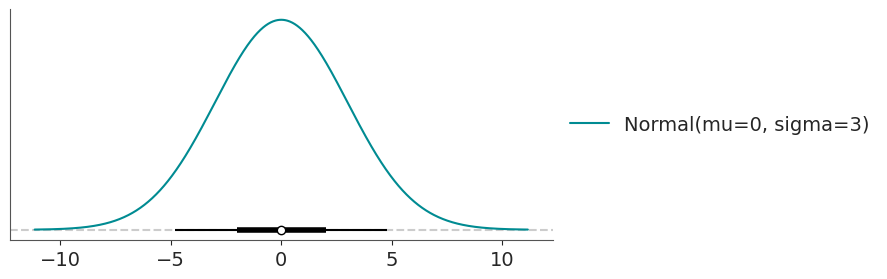

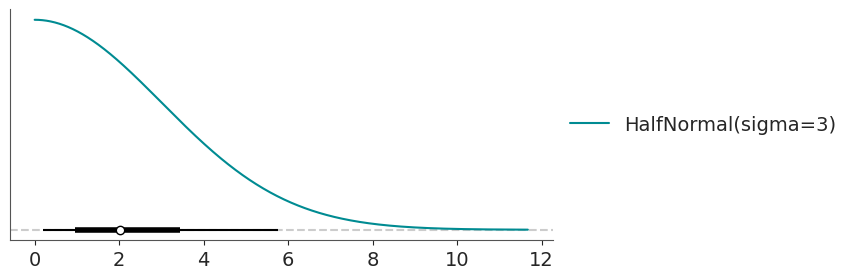

In [6]:
##########################
######### PRIORS #########
# Inspect variables
display(
    df_iv[[Y, T, Z, X]].describe().T.assign(**{
        "range": lambda df: df["max"] - df["min"]
    })
)

pz.Normal(mu=0, sigma=3).plot_pdf(pointinterval=True,figsize=(7, 3))
plt.show()
pz.HalfNormal(sigma=3).plot_pdf(pointinterval=True,figsize=(7, 3))
plt.show()

In [ ]:
############################
######### BAYESIAN #########

# Define instrumental variables
Z = "prime_elegible"
T = "prime_card"
Y = "pv"
X = "credit_score"

# Define coordinates
coords = {
    "obs": np.arange(df_iv.shape[0])
}

with pm.Model(coords=coords) as model_iv:
    # Define data containter
    Z = pm.Data(name="Z", value=df_iv[Z].values, dims="obs")
    # exogenous controls, shared by both eqs
    X_scaled = pm.Data(
        name="X",
        value=( (df_iv[X] - df_iv[X].mean()) / df_iv[X].std(ddof=1)).values,
        dims="obs"
    )
    T_obs = pm.Data(name="T", value=df_iv[T].values, dims="obs")
    Y_obs = pm.Data(name="Y", value=df_iv[Y].values, dims="obs")

    #################################################
    # FIRST STAGE: Model the Endogenous Treatment (T)
    # Priors for the instruments.
    # We use Normal distributions centered at 0 with small sigma as T is binary
    fs_intercept = pm.Normal(name="fs_intercept", mu=0, sigma=1)
    fs_Z = pm.Normal(name="fs_Z", mu=0, sigma=1) 
    fs_X_scaled = pm.Normal(name="fs_X_scaled", mu=0, sigma=1)
    fs_sigma_T = pm.HalfNormal(name="fs_sigma_T", sigma=1)

    # The expected value of the treatment based on our instruments and exogenous controls
    fs_mu_t = (
        fs_intercept + 
        fs_Z * Z + 
        fs_X_scaled * X_scaled
    )
    
    # Likelihood of the first stage. 
    # Even though T is binary, 2SLS uses a Linear Probability Model implicitly.
    # To match 2SLS exactly, we use a Normal likelihood here.
    T_likelihood = pm.Normal(
        name='T_obs',
        mu=fs_mu_t, sigma=fs_sigma_T,
        observed=T_obs,
        dims="obs"
    )


    ###############################################
    # THE CONTROL FUNCTION: Isolate the Endogeneity
    # The residual captures the unobserved confounding factors
    # which means the part of T that cannot be explained by X and Z.
    #
    # pm.Deterministic
    #   It doesn't change the model's inference at all — it's purely bookkeeping.
    #   It wraps an expression so PyMC (a) gives it a name and (b) stores its value at every posterior draw in the resulting InferenceData.
    #   In other words, it only tells PyMC "track this expression's value at every draw and store it in idata.posterior
    unobs_confounders_T_resid = pm.Deterministic(
        name='unobs_confounders_T_resid',
        var=T_likelihood - fs_mu_t,
        dims="obs"
    )


    #####################################
    # SECOND STAGE: Model the Outcome (Y)
    # Priors for the outcome equation
    # We use Normal distributions centered at 0 with large sigma as Y is in the thousands
    ss_intercept = pm.Normal(name="ss_intercept", mu=0, sigma=2000)
    causal_impact = pm.Normal(name="causal_impact", mu=0, sigma=2000)
    ss_unobs_conf = pm.Normal(name="ss_unobs_conf", mu=0, sigma=2000)
    ss_sigma_y = pm.HalfNormal(name='sigma_y', sigma=2000)
    
    # The expected value of Y. 
    # It depends on the treatment AND the confounding residual (unobs_confounders_T_resid)
    ss_mu_y = (
        ss_intercept + 
        causal_impact * T_obs + 
        ss_unobs_conf * unobs_confounders_T_resid
    )
    
    # Likelihood of the second stage
    Y_obs = pm.Normal('Y_obs', mu=ss_mu_y, sigma=ss_sigma_y, observed=Y_obs)


    ############################################
    # INFERENCE: Sample from the joint posterior
    # We sample simultaneously, automatically propagating uncertainty
    idata_iv = pm.sample(
        nuts_sampler="nutpie",
        draws=4_000,
        tune=4_000,
        target_accept=0.9,
        chains=N_CHAINS,
        cores=N_CHAINS,
        random_seed=SEED,
        progressbar=True,
        discard_tuned_samples=True,
        return_inferencedata=True,

    )

    pm.compute_log_likelihood(
        idata=idata_iv, extend_inferencedata=True
    )

# Save a checkpoint
idata_iv.to_netcdf(
    filepath=os.path.join(PYMC_MODELS_PATH, "model_iv.nc")
)

# Inspect idata
idata_iv

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [fs_intercept, fs_Z, fs_X_scaled, fs_sigma_T, ss_intercept, causal_impact, ss_unobs_conf, sigma_y]


Output()

Sampling 4 chains for 4_000 tune and 4_000 draw iterations (16_000 + 16_000 draws total) took 20 seconds.


Output()

<xarray.DataTree>
Group: /
├── Group: /posterior
│       Dimensions:                    (chain: 4, draw: 4000, obs: 10000)
│       Coordinates:
│         * chain                      (chain) int64 32B 0 1 2 3
│         * draw                       (draw) int64 32kB 0 1 2 3 ... 3996 3997 3998 3999
│         * obs                        (obs) int64 80kB 0 1 2 3 ... 9996 9997 9998 9999
│       Data variables:
│           fs_intercept               (chain, draw) float64 128kB 0.003018 ... -0.00...
│           fs_Z                       (chain, draw) float64 128kB 0.4143 ... 0.4227
│           fs_X_scaled                (chain, draw) float64 128kB 0.1997 ... 0.1901
│           ss_intercept               (chain, draw) float64 128kB 2.531e+03 ... 2.49...
│           causal_impact              (chain, draw) float64 128kB 642.6 645.9 ... 758.6
│           ss_unobs_conf              (chain, draw) float64 128kB -53.09 ... -281.2
│           fs_sigma_T                 (chain, draw) float64 128kB 0.2875 ... 0.2936
│           sigma_y                    (chain, draw) float64 128kB 1.703e+03 ... 1.70...
│           unobs_confounders_T_resid  (chain, draw, obs) float64 1GB -0.5977 ... -0.486
│       Attributes:
│           created_at:                 2026-07-23T17:41:47.445787+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.1.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.0.1
│           sample_dims:                ['chain', 'draw']
│           sampling_time:              20.29261565208435
│           tuning_steps:               4000
├── Group: /sample_stats
│       Dimensions:                (chain: 4, draw: 4000)
│       Coordinates:
│         * chain                  (chain) int64 32B 0 1 2 3
│         * draw                   (draw) int64 32kB 0 1 2 3 4 ... 3996 3997 3998 3999
│       Data variables: (12/18)
│           index_in_trajectory    (chain, draw) int64 128kB 2 -1 -1 2 -9 ... -1 -2 -9 2
│           reached_max_treedepth  (chain, draw) bool 16kB False False ... False False
│           max_energy_error       (chain, draw) float64 128kB 0.1185 ... -0.3064
│           perf_counter_diff      (chain, draw) float64 128kB 0.002035 ... 0.0009221
│           perf_counter_start     (chain, draw) float64 128kB 3.602e+03 ... 3.609e+03
│           energy                 (chain, draw) float64 128kB 9.043e+04 ... 9.044e+04
│           ...                     ...
│           step_size              (chain, draw) float64 128kB 0.4928 0.4928 ... 0.4901
│           process_time_diff      (chain, draw) float64 128kB 0.002038 ... 0.0009231
│           divergences            (chain, draw) int64 128kB 0 0 0 0 0 0 ... 0 0 0 0 0 0
│           diverging              (chain, draw) bool 16kB False False ... False False
│           acceptance_rate        (chain, draw) float64 128kB 0.9705 0.9961 ... 0.9025
│           largest_eigval         (chain, draw) float64 128kB nan nan nan ... nan nan
│       Attributes:
│           created_at:                 2026-07-23T17:41:47.470516+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.1.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.0.1
│           sample_dims:                ['chain', 'draw']
│           sampling_time:              20.29261565208435
│           tuning_steps:               4000
├── Group: /observed_data
│       Dimensions:      (obs: 10000, Y_obs_dim_0: 10000)
│       Coordinates:
│         * obs          (obs) int64 80kB 0 1 2 3 4 5 ... 9994 9995 9996 9997 9998 9999
│         * Y_obs_dim_0  (Y_obs_dim_0) int64 80kB 0 1 2 3 4 ... 9995 9996 9997 9998 9999
│       Data variables:
│           T_obs        (obs) float64 80kB 0.0 0.0 1.0 1.0 0.0 ... 0.0 0.0 1.0 0.0 0.0
│           Y_obs        (Y_obs_dim_0) float64 80kB 4.914e+03 5.638e+03 ... 

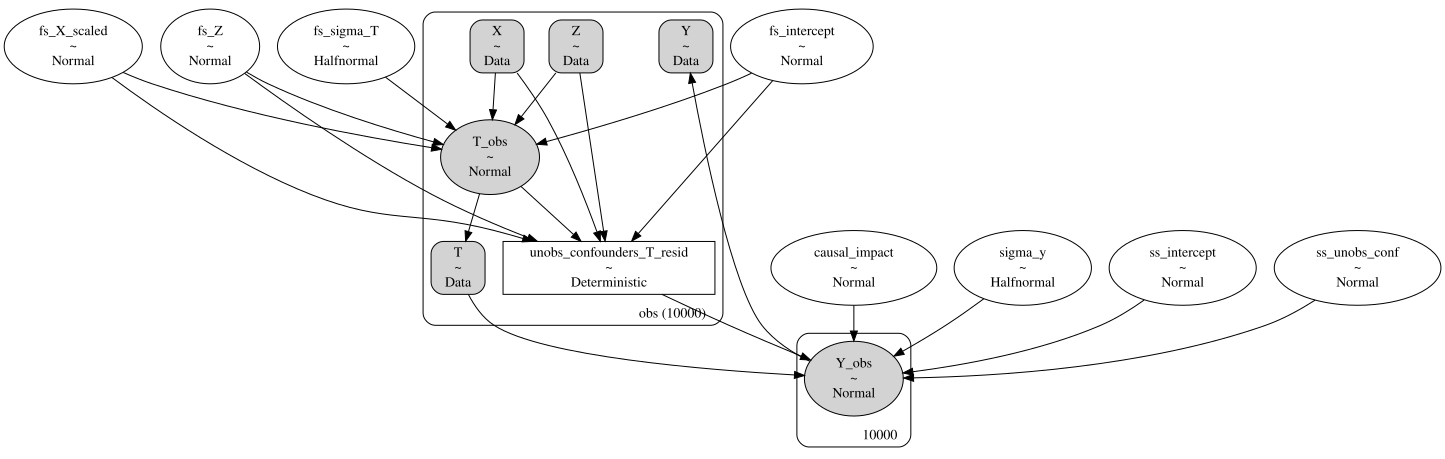

In [8]:
# plot graph
model_iv.to_graphviz()

In [9]:
# Get diverging draws
#   idata_sc.sample_stats["diverging"] dimensions -> (chain: 4; draw: 4000)
diverging_mask = idata_iv.sample_stats["diverging"].values.reshape(-1)
# Print report
print(f"Percentage of divergent draws: {diverging_mask.mean() * 100:.2f}% [threshold < 0.1%]")

Percentage of divergent draws: 0.00% [threshold < 0.1%]


In [10]:
# Inspect summary
# R hat
#   compute the variance between chains with the variance within chains
#   Ideally = 1, okay if < 1.01
# ESS (Effective Sample Size)
#   Less than the draws due to autocorrelation
#   At least 400 (100 ESS per chain) -> the higher the better
# MCSE - Monte Carlo Standard Error
#   Error introduced on MC posterior due to 
#   finite sampling and samples not being truely independent
#   It impact the precision of results
#   The pass criteria to check:
#       mcse_mean / sd (from the same table) below ~5–10%
#       If those all pass (R hat, ESS and MCSE), a U shape MCSE plot is fine as-is
#       the shape is just the normal signature of tail quantiles being harder to pin down.
summary = az.summary(
    data=idata_iv,
    var_names=["causal_impact", "ss_unobs_conf"],
    filter_vars=None,
    group='posterior', coords=None, sample_dims=None,
    kind='all', fmt='wide', ci_prob=0.95, ci_kind="hdi",
    round_to='auto', skipna=False
)

# Relative MCSE: how big is the sampling error compared to the posterior's own spread?
#   mcse_mean_pct = MCSE of the posterior mean, as a % of the posterior SD.
#       Rule of thumb: < 5–10% is fine; 
#       higher means you'd need more draws to trust the reported mean/HDI to that many significant digits.
#   mcse_sd_pct = same idea for the SD estimate.
summary["mcse_mean_pct"] = summary["mcse_mean"].astype(float) / summary["sd"].astype(float)
summary["mcse_sd_pct"]   = summary["mcse_sd"].astype(float)   / summary["sd"].astype(float)
summary: pd.DataFrame = summary.astype("float")
summary

,mean,sd,hdi95_lb,hdi95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd,mcse_mean_pct,mcse_sd_pct
causal_impact,659.0,59.5,540.0,780.0,9817.0,11027.0,1.0,0.60,0.42,0.010084,0.007059
ss_unobs_conf,-141.0,84.0,-310.0,24.0,10630.0,12057.0,1.0,0.82,0.58,0.009762,0.006905


In [11]:
# Inspect problematic donors
problematic_params = summary[
    (
        summary.r_hat > 1.01
    ) | (
        summary.ess_bulk < N_CHAINS*100
    ) | (
        summary.ess_tail < N_CHAINS*100
    ) | (
        summary.mcse_mean_pct > 0.05
    )
]
problematic_params

,mean,sd,hdi95_lb,hdi95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd,mcse_mean_pct,mcse_sd_pct


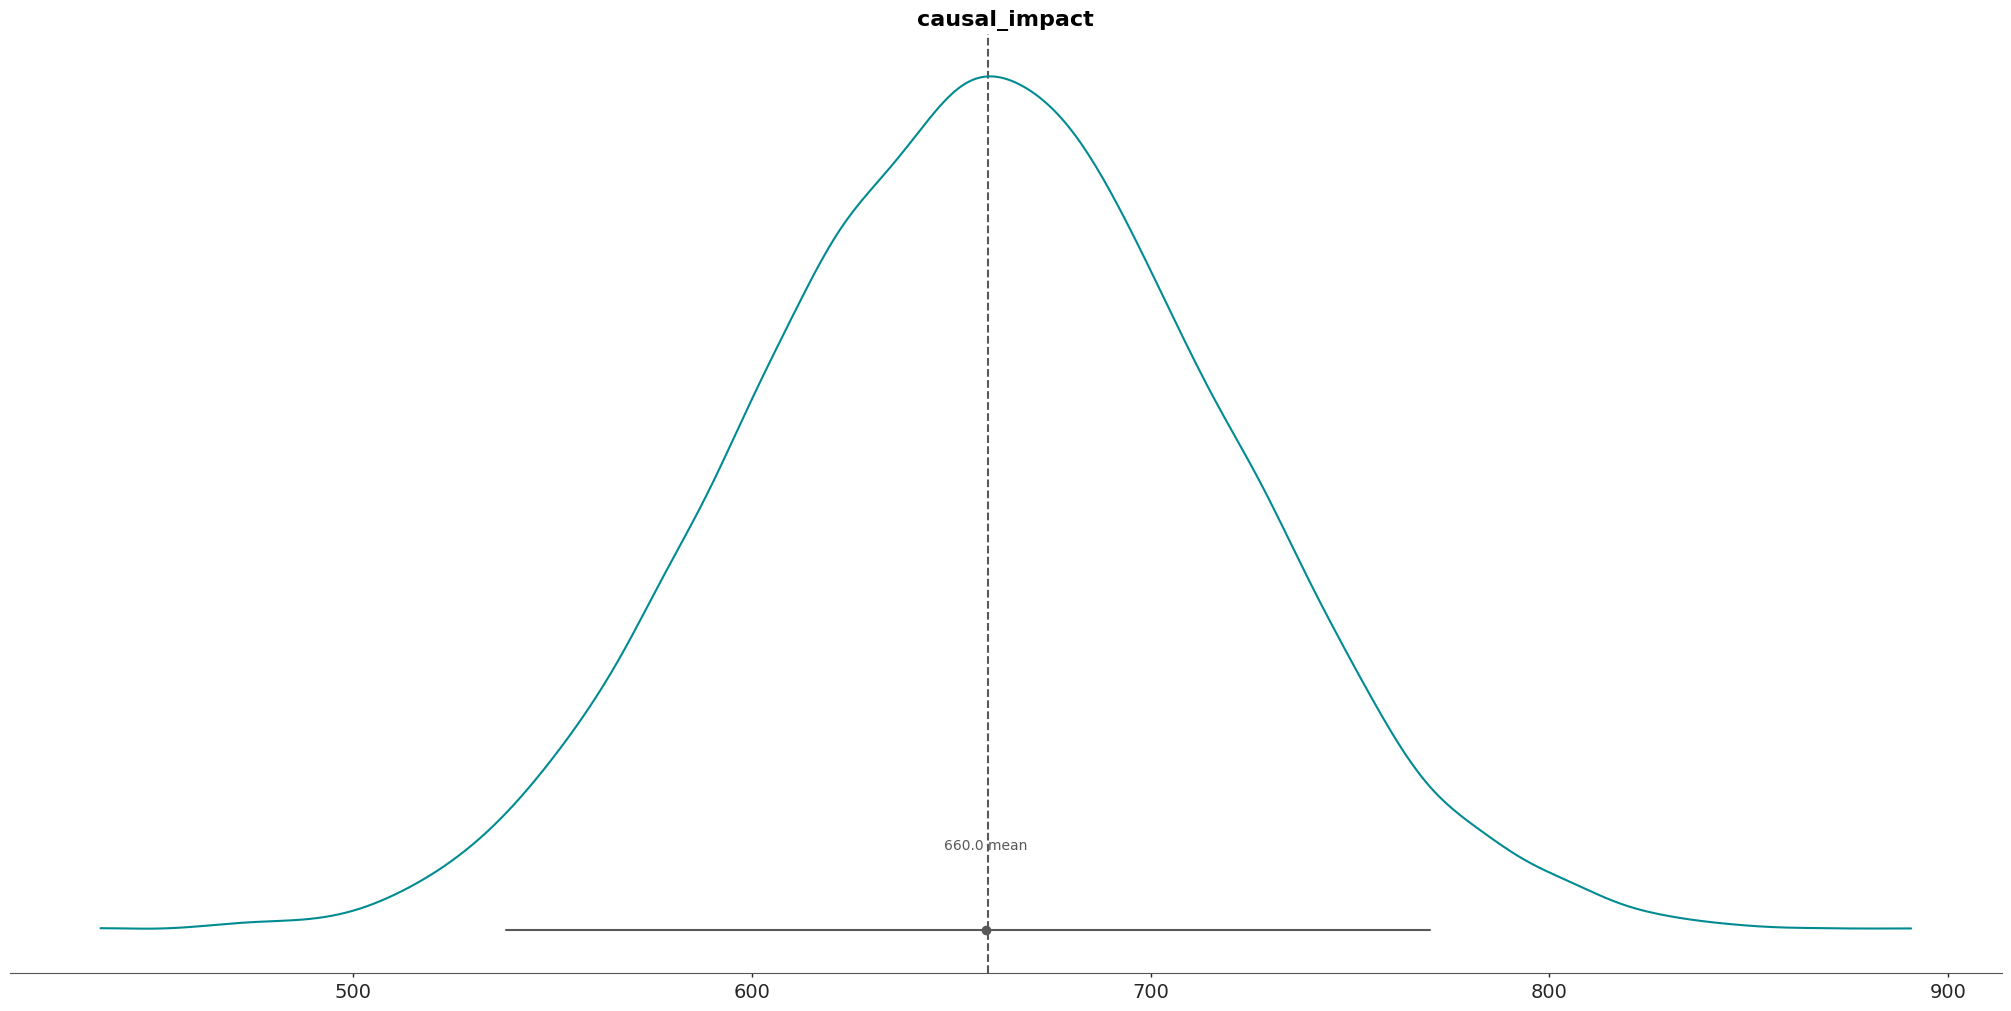

In [12]:
# Inspect posteriors
pc = az.plot_dist(
    dt=idata_iv,
    var_names=["causal_impact"],
    filter_vars=None,
    group='posterior', coords=None, sample_dims=None,
    kind=None, point_estimate="mean",
    ci_kind="hdi", ci_prob=0.95, stats=None,
    visuals={"point_estimate_text": True},
    figure_kwargs={"figsize": (20, 10)},
)
az.add_lines(
    plot_collection=pc,
    values={
        "causal_impact": iv_model.params[T]
    },
    orientation="vertical"
);